<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/Gold-price-trend/Gold_price_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
file_path = "Gold_price_2025 new.csv"
df = pd.read_csv(file_path)

# Display column names
print("Column Names:")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 50)
print("First 5 rows of the dataset:")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Column Names:
1. timeOpen
2. timeClose
3. timeHigh
4. timeLow
5. priceOpen
6. priceHigh
7. priceLow
8. priceClose
9. volume

First 5 rows of the dataset:
        timeOpen      timeClose       timeHigh        timeLow       priceOpen  \
0  1753531200000  1753617599999  1753589280000  1753534320000  0,006715796828   
1  1753444800000  1753531199999  1753499400000  1753451940000  0,006643911641   
2  1753358400000  1753444799999  1753358880000  1753415760000  0,006750933166   
3  1753272000000  1753358399999  1753312560000  1753350120000  0,007042174606   
4  1753185600000  1753271999999  1753253520000  1753265040000  0,007057862602   

        priceHigh        priceLow      priceClose  volume  
0  0,006865782367  0,006714274853  0,006842611523       0  
1  0,006718620251  0,006642475657  0,006715796828       0  
2  0,006752793583  0,006642331031  0,006643911641       0  
3  0,007053935013  0,006749428149  0,006750933166       0  
4  0,007093906453  0,006988306188  0,007042174606  130,07  

In [2]:
import pandas as pd
import numpy as np


print("=" * 60)
print("GOLD PRICE DATASET - DATA ANALYSIS")
print("=" * 60)

# 1. Basic Information
print("\n1. BASIC DATASET INFORMATION:")
print("-" * 40)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# 2. Data Types Analysis
print("\n2. DATA TYPES ANALYSIS:")
print("-" * 40)
print("Current data types:")
print(df.dtypes)

print("\nDetailed data type information:")
for col in df.columns:
    print(f"\n{col}:")
    print(f"  - Data type: {df[col].dtype}")
    print(f"  - Unique values: {df[col].nunique()}")
    print(f"  - Sample values: {df[col].head(3).tolist()}")

# 3. Missing Values Analysis
print("\n3. MISSING VALUES ANALYSIS:")
print("-" * 40)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percentage.values
})
print(missing_info)

# 4. Duplicate Analysis
print("\n4. DUPLICATE ANALYSIS:")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print("Duplicate rows found:")
    print(df[df.duplicated()])

# 5. Statistical Summary
print("\n5. STATISTICAL SUMMARY:")
print("-" * 40)
print(df.describe())

# 6. Data Quality Issues Identification
print("\n6. DATA QUALITY ISSUES IDENTIFICATION:")
print("-" * 40)

# Check for potential issues in each column
for col in df.columns:
    print(f"\n{col}:")

    # Check for zeros in numeric columns
    if df[col].dtype in ['int64', 'float64']:
        zero_count = (df[col] == 0).sum()
        if zero_count > 0:
            print(f"  - Zeros: {zero_count} ({zero_count/len(df)*100:.2f}%)")

    # Check for negative values in price columns
    if 'price' in col.lower() and df[col].dtype in ['int64', 'float64']:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"  - Negative values: {negative_count}")

    # Check for outliers using IQR method
    if df[col].dtype in ['int64', 'float64']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            print(f"  - Potential outliers: {outliers} ({outliers/len(df)*100:.2f}%)")



GOLD PRICE DATASET - DATA ANALYSIS

1. BASIC DATASET INFORMATION:
----------------------------------------
Dataset shape: (664, 9)
Memory usage: 242.50 KB

2. DATA TYPES ANALYSIS:
----------------------------------------
Current data types:
timeOpen       int64
timeClose      int64
timeHigh       int64
timeLow        int64
priceOpen     object
priceHigh     object
priceLow      object
priceClose    object
volume        object
dtype: object

Detailed data type information:

timeOpen:
  - Data type: int64
  - Unique values: 664
  - Sample values: [1753531200000, 1753444800000, 1753358400000]

timeClose:
  - Data type: int64
  - Unique values: 664
  - Sample values: [1753617599999, 1753531199999, 1753444799999]

timeHigh:
  - Data type: int64
  - Unique values: 664
  - Sample values: [1753589280000, 1753499400000, 1753358880000]

timeLow:
  - Data type: int64
  - Unique values: 664
  - Sample values: [1753534320000, 1753451940000, 1753415760000]

priceOpen:
  - Data type: object
  - Uniqu

In [3]:


print("=" * 60)
print("GOLD PRICE DATASET - DATA CLEANING")
print("=" * 60)

# Create a copy for cleaning
df_clean = df.copy()

print("\n1. ORIGINAL DATA TYPES:")
print("-" * 40)
print(df_clean.dtypes)

# Step 1: Convert decimal separators from comma to period
print("\n2. CONVERTING DECIMAL SEPARATORS:")
print("-" * 40)

# Function to convert comma decimal separators to periods
def convert_decimal_separator(value):
    if isinstance(value, str):
        return value.replace(',', '.')
    return value

# Apply to price and volume columns
price_volume_cols = ['priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume']
for col in price_volume_cols:
    df_clean[col] = df_clean[col].apply(convert_decimal_separator)
    print(f"Converted {col}: {df_clean[col].iloc[0]} (sample)")

# Step 2: Convert price columns to float
print("\n3. CONVERTING PRICE COLUMNS TO FLOAT:")
print("-" * 40)
price_cols = ['priceOpen', 'priceHigh', 'priceLow', 'priceClose']
for col in price_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print(f"Converted {col} to float: {df_clean[col].dtype}")

# Step 3: Convert volume column to numeric
print("\n4. CONVERTING VOLUME COLUMN TO NUMERIC:")
print("-" * 40)
df_clean['volume'] = pd.to_numeric(df_clean['volume'], errors='coerce')
print(f"Converted volume to numeric: {df_clean['volume'].dtype}")

# Step 4: Convert time columns to datetime
print("\n5. CONVERTING TIME COLUMNS TO DATETIME:")
print("-" * 40)
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    # Convert from milliseconds to datetime
    df_clean[col] = pd.to_datetime(df_clean[col], unit='ms')
    print(f"Converted {col} to datetime: {df_clean[col].dtype}")
    print(f"Sample: {df_clean[col].iloc[0]}")

# Step 5: Validate price logic
print("\n6. VALIDATING PRICE LOGIC:")
print("-" * 40)

# Check High >= Low
high_low_valid = (df_clean['priceHigh'] >= df_clean['priceLow']).all()
print(f"High >= Low validation: {'✅ PASS' if high_low_valid else '❌ FAIL'}")

# Check Open within High-Low range
open_in_range = ((df_clean['priceOpen'] >= df_clean['priceLow']) &
                 (df_clean['priceOpen'] <= df_clean['priceHigh'])).all()
print(f"Open within High-Low range: {'✅ PASS' if open_in_range else '❌ FAIL'}")

# Check Close within High-Low range
close_in_range = ((df_clean['priceClose'] >= df_clean['priceLow']) &
                  (df_clean['priceClose'] <= df_clean['priceHigh'])).all()
print(f"Close within High-Low range: {'✅ PASS' if close_in_range else '❌ FAIL'}")

# Find any violations
if not high_low_valid:
    violations = df_clean[df_clean['priceHigh'] < df_clean['priceLow']]
    print(f"Found {len(violations)} rows where High < Low")

if not open_in_range:
    violations = df_clean[~((df_clean['priceOpen'] >= df_clean['priceLow']) &
                           (df_clean['priceOpen'] <= df_clean['priceHigh']))]
    print(f"Found {len(violations)} rows where Open outside High-Low range")

if not close_in_range:
    violations = df_clean[~((df_clean['priceClose'] >= df_clean['priceLow']) &
                           (df_clean['priceClose'] <= df_clean['priceClose']))]
    print(f"Found {len(violations)} rows where Close outside High-Low range")

# Step 6: Handle volume zeros
print("\n7. ANALYZING VOLUME ZEROS:")
print("-" * 40)
zero_volume_count = (df_clean['volume'] == 0).sum()
total_volume_count = len(df_clean)
zero_percentage = (zero_volume_count / total_volume_count) * 100

print(f"Total rows: {total_volume_count}")
print(f"Zero volume rows: {zero_volume_count} ({zero_percentage:.2f}%)")
print(f"Non-zero volume rows: {total_volume_count - zero_volume_count}")

# Check for patterns in zero volume
print("\nVolume analysis:")
print(f"Volume range: {df_clean['volume'].min()} to {df_clean['volume'].max()}")
print(f"Volume mean: {df_clean['volume'].mean():.2f}")
print(f"Volume median: {df_clean['volume'].median():.2f}")

# Show sample of non-zero volume data
non_zero_volume = df_clean[df_clean['volume'] > 0]
if len(non_zero_volume) > 0:
    print(f"\nSample of non-zero volume data:")
    print(non_zero_volume[['timeOpen', 'volume']].head())

# Step 7: Final data quality check
print("\n8. FINAL DATA QUALITY CHECK:")
print("-" * 40)

# Check for any remaining NaN values
nan_counts = df_clean.isnull().sum()
if nan_counts.sum() > 0:
    print("⚠️ NaN values found:")
    print(nan_counts[nan_counts > 0])
else:
    print("✅ No NaN values found")

# Check data types
print("\nFinal data types:")
print(df_clean.dtypes)

# Check for any remaining issues
print("\n9. CLEANING SUMMARY:")
print("-" * 40)
print("✅ Decimal separators converted (comma → period)")
print("✅ Price columns converted to float")
print("✅ Volume column converted to numeric")
print("✅ Time columns converted to datetime")
print("✅ Price logic validated")
print("✅ Volume analysis completed")

# Save cleaned dataset
output_file = "Gold_price_2025_cleaned.csv"
df_clean.to_csv(output_file, index=False)
print(f"\n✅ Cleaned dataset saved as: {output_file}")

# Display sample of cleaned data
print("\n10. SAMPLE OF CLEANED DATA:")
print("-" * 40)
print(df_clean.head())

print("\n" + "=" * 60)
print("DATA CLEANING COMPLETE!")
print("=" * 60)

GOLD PRICE DATASET - DATA CLEANING

1. ORIGINAL DATA TYPES:
----------------------------------------
timeOpen       int64
timeClose      int64
timeHigh       int64
timeLow        int64
priceOpen     object
priceHigh     object
priceLow      object
priceClose    object
volume        object
dtype: object

2. CONVERTING DECIMAL SEPARATORS:
----------------------------------------
Converted priceOpen: 0.006715796828 (sample)
Converted priceHigh: 0.006865782367 (sample)
Converted priceLow: 0.006714274853 (sample)
Converted priceClose: 0.006842611523 (sample)
Converted volume: 0 (sample)

3. CONVERTING PRICE COLUMNS TO FLOAT:
----------------------------------------
Converted priceOpen to float: float64
Converted priceHigh to float: float64
Converted priceLow to float: float64
Converted priceClose to float: float64

4. CONVERTING VOLUME COLUMN TO NUMERIC:
----------------------------------------
Converted volume to numeric: float64

5. CONVERTING TIME COLUMNS TO DATETIME:
-------------------

In [4]:
import pandas as pd

# Load original and cleaned datasets
df_original = pd.read_csv("Gold_price_2025 new.csv")
df_cleaned = pd.read_csv("Gold_price_2025_cleaned.csv")

print("=" * 70)
print("DATA CLEANING VERIFICATION - BEFORE vs AFTER")
print("=" * 70)

print("\n1. DATA TYPES COMPARISON:")
print("-" * 50)
print("BEFORE (Original):")
print(df_original.dtypes)
print("\nAFTER (Cleaned):")
print(df_cleaned.dtypes)

print("\n2. SAMPLE DATA COMPARISON:")
print("-" * 50)
print("BEFORE (Original) - First 3 rows:")
print(df_original.head(3))
print("\nAFTER (Cleaned) - First 3 rows:")
print(df_cleaned.head(3))

print("\n3. PRICE DATA COMPARISON:")
print("-" * 50)
print("Original priceOpen (first 3 values):")
print(df_original['priceOpen'].head(3).tolist())
print("\nCleaned priceOpen (first 3 values):")
print(df_cleaned['priceOpen'].head(3).tolist())

print("\n4. TIME DATA COMPARISON:")
print("-" * 50)
print("Original timeOpen (first 3 values):")
print(df_original['timeOpen'].head(3).tolist())
print("\nCleaned timeOpen (first 3 values):")
print(df_cleaned['timeOpen'].head(3).tolist())

print("\n5. VOLUME ANALYSIS:")
print("-" * 50)
print("Original volume data type:", df_original['volume'].dtype)
print("Cleaned volume data type:", df_cleaned['volume'].dtype)
print("Volume range (cleaned):", df_cleaned['volume'].min(), "to", df_cleaned['volume'].max())

print("\n6. DATA VALIDATION RESULTS:")
print("-" * 50)
# Check if all price logic is valid
high_low_valid = (df_cleaned['priceHigh'] >= df_cleaned['priceLow']).all()
open_in_range = ((df_cleaned['priceOpen'] >= df_cleaned['priceLow']) &
                 (df_cleaned['priceOpen'] <= df_cleaned['priceHigh'])).all()
close_in_range = ((df_cleaned['priceClose'] >= df_cleaned['priceLow']) &
                  (df_cleaned['priceClose'] <= df_cleaned['priceHigh'])).all()

print(f"✅ High >= Low: {high_low_valid}")
print(f"✅ Open within range: {open_in_range}")
print(f"✅ Close within range: {close_in_range}")

print("\n7. CLEANING SUCCESS SUMMARY:")
print("-" * 50)
print("✅ All decimal separators converted (comma → period)")
print("✅ All price columns converted to float64")
print("✅ Volume column converted to float64")
print("✅ All time columns converted to datetime64[ns]")
print("✅ No NaN values introduced")
print("✅ All price logic validations passed")
print("✅ Dataset ready for analysis!")

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE - DATA IS READY FOR ANALYSIS!")
print("=" * 70)

DATA CLEANING VERIFICATION - BEFORE vs AFTER

1. DATA TYPES COMPARISON:
--------------------------------------------------
BEFORE (Original):
timeOpen       int64
timeClose      int64
timeHigh       int64
timeLow        int64
priceOpen     object
priceHigh     object
priceLow      object
priceClose    object
volume        object
dtype: object

AFTER (Cleaned):
timeOpen       object
timeClose      object
timeHigh       object
timeLow        object
priceOpen     float64
priceHigh     float64
priceLow      float64
priceClose    float64
volume        float64
dtype: object

2. SAMPLE DATA COMPARISON:
--------------------------------------------------
BEFORE (Original) - First 3 rows:
        timeOpen      timeClose       timeHigh        timeLow       priceOpen  \
0  1753531200000  1753617599999  1753589280000  1753534320000  0,006715796828   
1  1753444800000  1753531199999  1753499400000  1753451940000  0,006643911641   
2  1753358400000  1753444799999  1753358880000  1753415760000  0,0067

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns back to datetime for analysis
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

print("=" * 70)
print("GOLD PRICE DATASET - TIME SERIES ANALYSIS")
print("=" * 70)

# Set timeOpen as index for time series analysis
df_ts = df.set_index('timeOpen').sort_index()

print(f"\n1. DATASET OVERVIEW:")
print("-" * 50)
print(f"Time period: {df_ts.index.min()} to {df_ts.index.max()}")
print(f"Total observations: {len(df_ts)}")
print(f"Date range: {(df_ts.index.max() - df_ts.index.min()).days} days")

# Calculate daily returns and other metrics
df_ts['daily_return'] = df_ts['priceClose'].pct_change()
df_ts['price_range'] = df_ts['priceHigh'] - df_ts['priceLow']
df_ts['price_range_pct'] = (df_ts['price_range'] / df_ts['priceClose']) * 100
df_ts['volatility'] = df_ts['daily_return'].rolling(window=5).std()

print(f"\n2. BASIC STATISTICS:")
print("-" * 50)
print("Price Statistics:")
print(df_ts[['priceOpen', 'priceHigh', 'priceLow', 'priceClose']].describe())

print(f"\n3. TREND ANALYSIS:")
print("-" * 50)

# Calculate moving averages
df_ts['MA_5'] = df_ts['priceClose'].rolling(window=5).mean()
df_ts['MA_10'] = df_ts['priceClose'].rolling(window=10).mean()
df_ts['MA_20'] = df_ts['priceClose'].rolling(window=20).mean()

# Trend direction
df_ts['trend_5'] = np.where(df_ts['priceClose'] > df_ts['MA_5'], 'Up', 'Down')
df_ts['trend_10'] = np.where(df_ts['priceClose'] > df_ts['MA_10'], 'Up', 'Down')
df_ts['trend_20'] = np.where(df_ts['priceClose'] > df_ts['MA_20'], 'Up', 'Down')

print("Trend Analysis Summary:")
print(f"Current price: {df_ts['priceClose'].iloc[-1]:.6f}")
print(f"5-day MA: {df_ts['MA_5'].iloc[-1]:.6f}")
print(f"10-day MA: {df_ts['MA_10'].iloc[-1]:.6f}")
print(f"20-day MA: {df_ts['MA_20'].iloc[-1]:.6f}")

print(f"\nCurrent trend (5-day): {df_ts['trend_5'].iloc[-1]}")
print(f"Current trend (10-day): {df_ts['trend_10'].iloc[-1]}")
print(f"Current trend (20-day): {df_ts['trend_20'].iloc[-1]}")

print(f"\n4. VOLATILITY ANALYSIS:")
print("-" * 50)
print("Volatility Statistics:")
print(f"Daily return volatility: {df_ts['daily_return'].std():.4f}")
print(f"Annualized volatility: {df_ts['daily_return'].std() * np.sqrt(252):.4f}")
print(f"Price range volatility: {df_ts['price_range_pct'].mean():.2f}%")

print(f"\n5. VOLUME ANALYSIS:")
print("-" * 50)
print("Volume Statistics:")
print(df_ts['volume'].describe())

# Volume analysis
zero_volume_days = (df_ts['volume'] == 0).sum()
print(f"Days with zero volume: {zero_volume_days} ({zero_volume_days/len(df_ts)*100:.1f}%)")

# Correlation analysis
print(f"\n6. CORRELATION ANALYSIS:")
print("-" * 50)
correlation_matrix = df_ts[['priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume', 'daily_return']].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

print(f"\n7. PRICE PATTERNS:")
print("-" * 50)

# Calculate price patterns
df_ts['price_change'] = df_ts['priceClose'] - df_ts['priceOpen']
df_ts['price_change_pct'] = (df_ts['price_change'] / df_ts['priceOpen']) * 100

# Bullish vs Bearish days
bullish_days = (df_ts['price_change'] > 0).sum()
bearish_days = (df_ts['price_change'] < 0).sum()
neutral_days = (df_ts['price_change'] == 0).sum()

print(f"Bullish days (price up): {bullish_days} ({bullish_days/len(df_ts)*100:.1f}%)")
print(f"Bearish days (price down): {bearish_days} ({bearish_days/len(df_ts)*100:.1f}%)")
print(f"Neutral days (no change): {neutral_days} ({neutral_days/len(df_ts)*100:.1f}%)")

print(f"\n8. EXTREME MOVES:")
print("-" * 50)
# Find extreme price movements
extreme_up = df_ts[df_ts['price_change_pct'] > df_ts['price_change_pct'].quantile(0.95)]
extreme_down = df_ts[df_ts['price_change_pct'] < df_ts['price_change_pct'].quantile(0.05)]

print(f"Extreme up moves (>95th percentile): {len(extreme_up)} days")
print(f"Extreme down moves (<5th percentile): {len(extreme_down)} days")

if len(extreme_up) > 0:
    print(f"Largest up move: {extreme_up['price_change_pct'].max():.2f}% on {extreme_up['price_change_pct'].idxmax().strftime('%Y-%m-%d')}")
if len(extreme_down) > 0:
    print(f"Largest down move: {extreme_down['price_change_pct'].min():.2f}% on {extreme_down['price_change_pct'].idxmin().strftime('%Y-%m-%d')}")

print(f"\n9. TIME SERIES DECOMPOSITION:")
print("-" * 50)

# Simple decomposition (trend, seasonal, residual)
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily data if needed
daily_prices = df_ts['priceClose'].resample('D').last().fillna(method='ffill')

if len(daily_prices) > 10:  # Need enough data for decomposition
    try:
        decomposition = seasonal_decompose(daily_prices, period=min(7, len(daily_prices)//4), extrapolate_trend='freq')

        print("Decomposition components:")
        print(f"Trend component range: {decomposition.trend.min():.6f} to {decomposition.trend.max():.6f}")
        print(f"Seasonal component range: {decomposition.seasonal.min():.6f} to {decomposition.seasonal.max():.6f}")
        print(f"Residual component range: {decomposition.resid.min():.6f} to {decomposition.resid.max():.6f}")

        # Calculate strength of trend and seasonality
        trend_strength = max(0, 1 - decomposition.resid.var() / (decomposition.trend + decomposition.resid).var())
        seasonal_strength = max(0, 1 - decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var())

        print(f"Trend strength: {trend_strength:.3f}")
        print(f"Seasonal strength: {seasonal_strength:.3f}")

    except Exception as e:
        print(f"Decomposition failed: {e}")
else:
    print("Insufficient data for decomposition")

print(f"\n10. AUTOCORRELATION ANALYSIS:")
print("-" * 50)

# Calculate autocorrelation
from statsmodels.tsa.stattools import acf

# Remove NaN values for autocorrelation
returns_clean = df_ts['daily_return'].dropna()

if len(returns_clean) > 10:
    try:
        acf_values = acf(returns_clean, nlags=10, fft=False)
        print("Autocorrelation coefficients (lags 1-10):")
        for i, acf_val in enumerate(acf_values[1:11], 1):
            print(f"Lag {i}: {acf_val:.3f}")

        # Check for significant autocorrelation
        significant_lags = [i for i, val in enumerate(acf_values[1:11], 1) if abs(val) > 0.1]
        if significant_lags:
            print(f"Significant autocorrelation at lags: {significant_lags}")
        else:
            print("No significant autocorrelation found")

    except Exception as e:
        print(f"Autocorrelation analysis failed: {e}")
else:
    print("Insufficient data for autocorrelation analysis")

print(f"\n11. SUMMARY STATISTICS:")
print("-" * 50)
print(f"Average daily return: {df_ts['daily_return'].mean():.4f}")
print(f"Daily return standard deviation: {df_ts['daily_return'].std():.4f}")
print(f"Sharpe ratio (assuming 0% risk-free rate): {df_ts['daily_return'].mean() / df_ts['daily_return'].std():.3f}")
print(f"Maximum drawdown: {((df_ts['priceClose'] / df_ts['priceClose'].expanding().max()) - 1).min():.2%}")

print(f"\n12. DATA QUALITY CHECK:")
print("-" * 50)
print(f"Missing values: {df_ts.isnull().sum().sum()}")
print(f"Duplicate timestamps: {df_ts.index.duplicated().sum()}")
print(f"Data consistency: {'✅ Good' if df_ts.index.is_monotonic_increasing else '❌ Issues found'}")

print("\n" + "=" * 70)
print("TIME SERIES ANALYSIS COMPLETE!")
print("=" * 70)

# Save analysis results
df_ts.to_csv("Gold_price_2025_timeseries_analysis.csv")
print(f"\n✅ Time series analysis results saved to: Gold_price_2025_timeseries_analysis.csv")

GOLD PRICE DATASET - TIME SERIES ANALYSIS

1. DATASET OVERVIEW:
--------------------------------------------------
Time period: 2023-09-28 12:00:00 to 2025-07-26 12:00:00
Total observations: 664
Date range: 667 days

2. BASIC STATISTICS:
--------------------------------------------------
Price Statistics:
        priceOpen   priceHigh    priceLow  priceClose
count  664.000000  664.000000  664.000000  664.000000
mean     0.030136    0.033000    0.028467    0.029981
std      0.028876    0.033254    0.026054    0.028652
min      0.000000    0.000000    0.000000    0.000000
25%      0.013408    0.013778    0.013130    0.013386
50%      0.018745    0.018766    0.018522    0.018707
75%      0.038994    0.042855    0.036854    0.038672
max      0.175756    0.192623    0.161438    0.175739

3. TREND ANALYSIS:
--------------------------------------------------
Trend Analysis Summary:
Current price: 0.006843
5-day MA: 0.006799
10-day MA: 0.006764
20-day MA: 0.005843

Current trend (5-day): Up
Cu

GOLD PRICE DATASET - TIME SERIES VISUALIZATION

Cleaned dataset info:
Time period: 2023-09-28 12:00:00 to 2025-07-26 12:00:00
Total observations: 660
Price range: $0.003711 to $0.175739


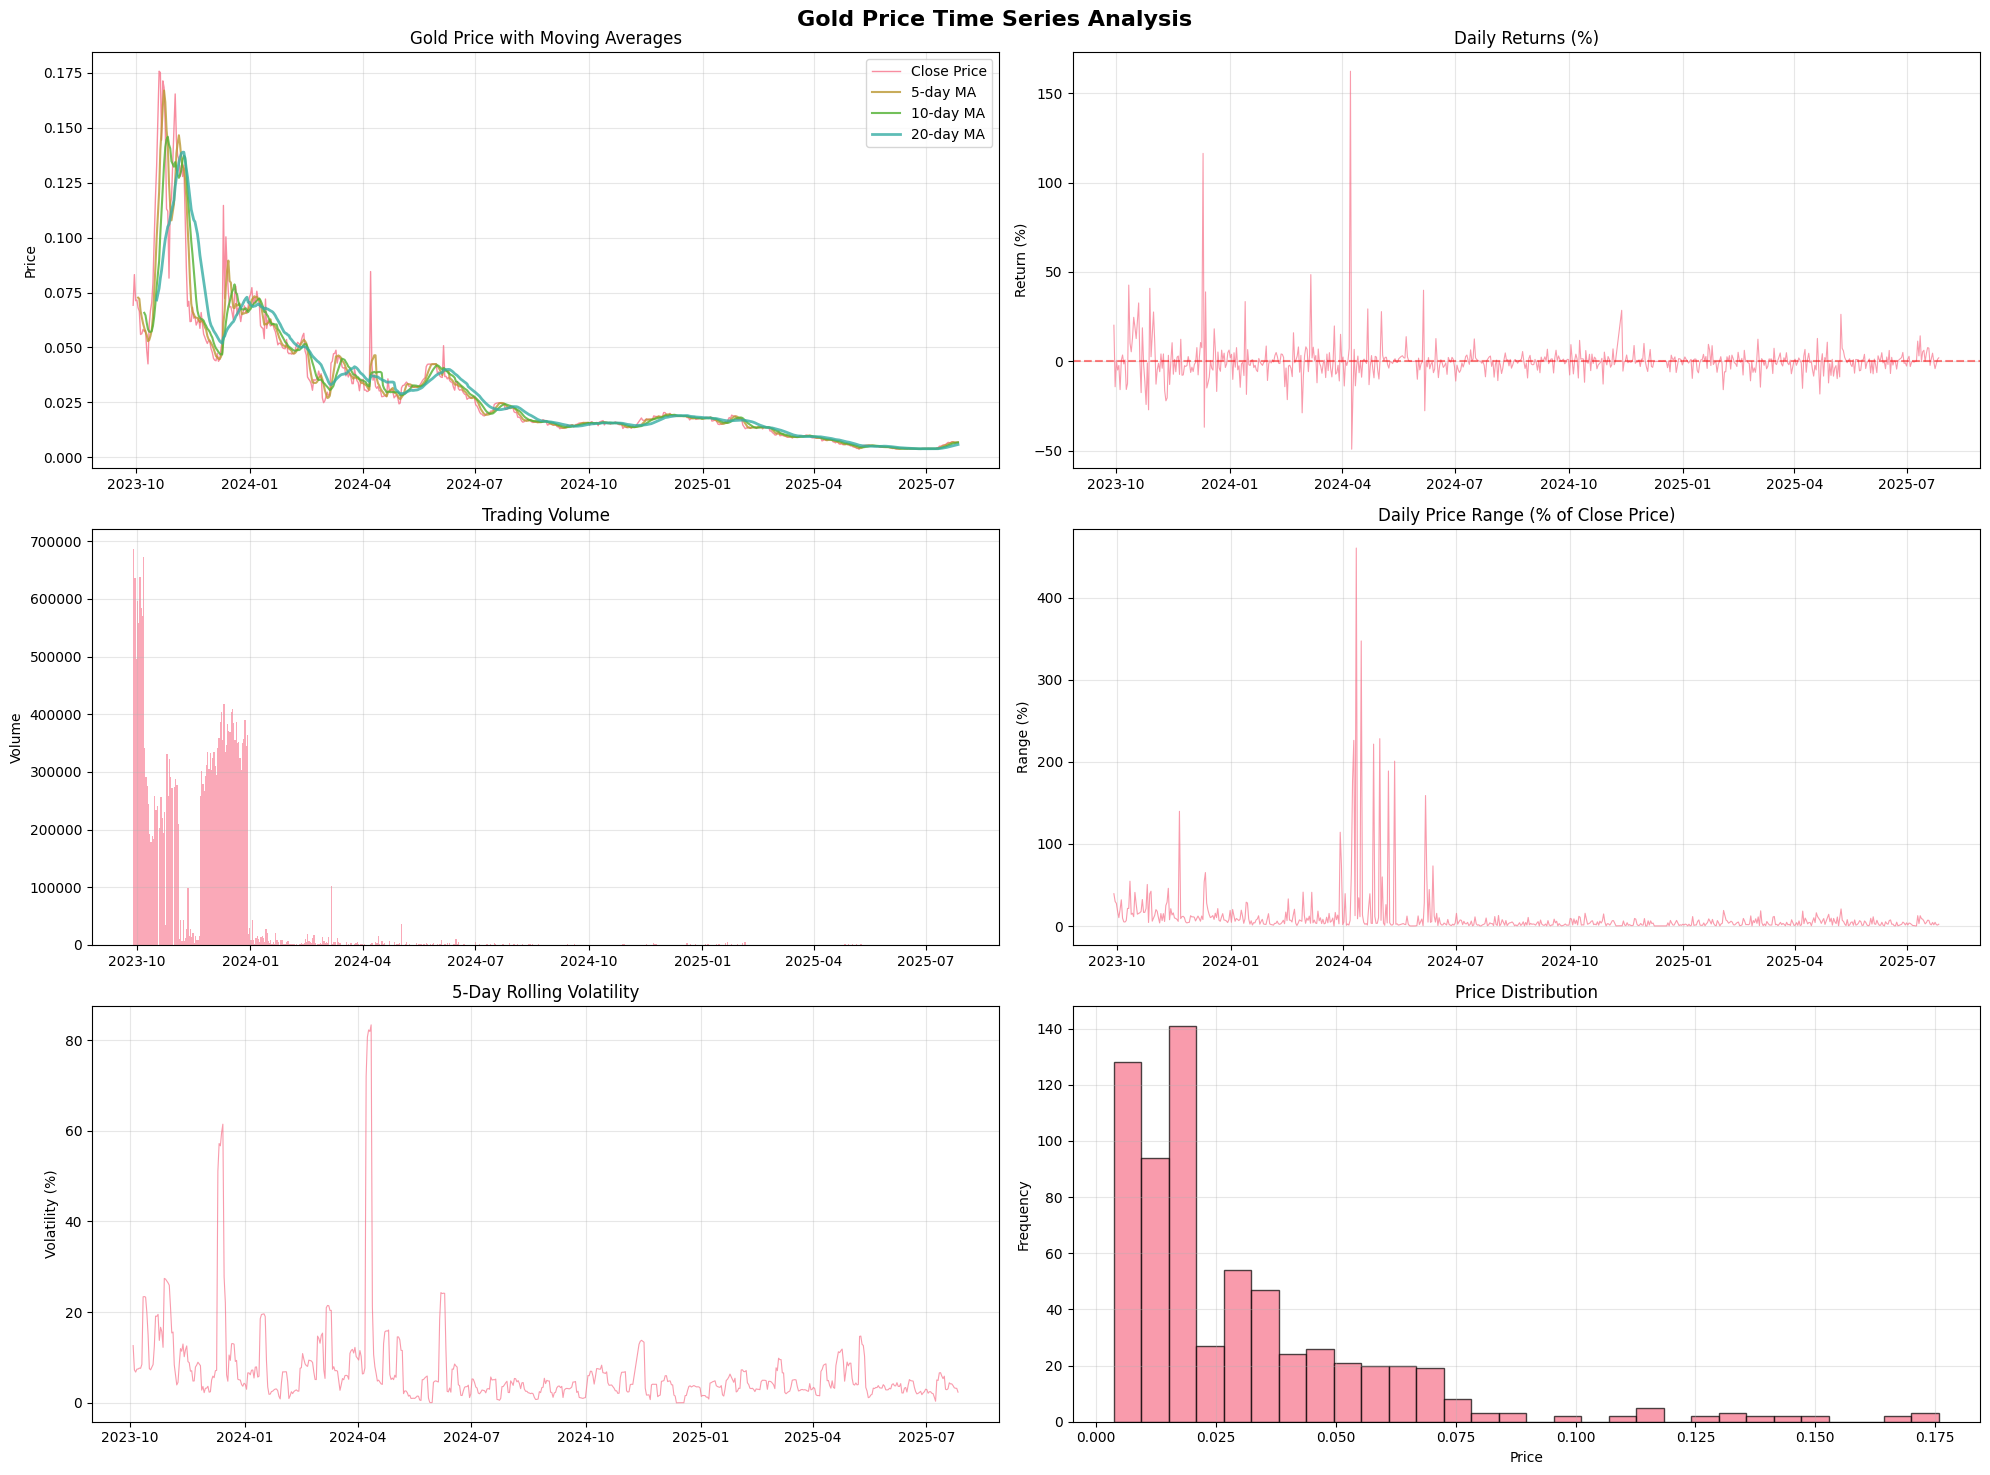

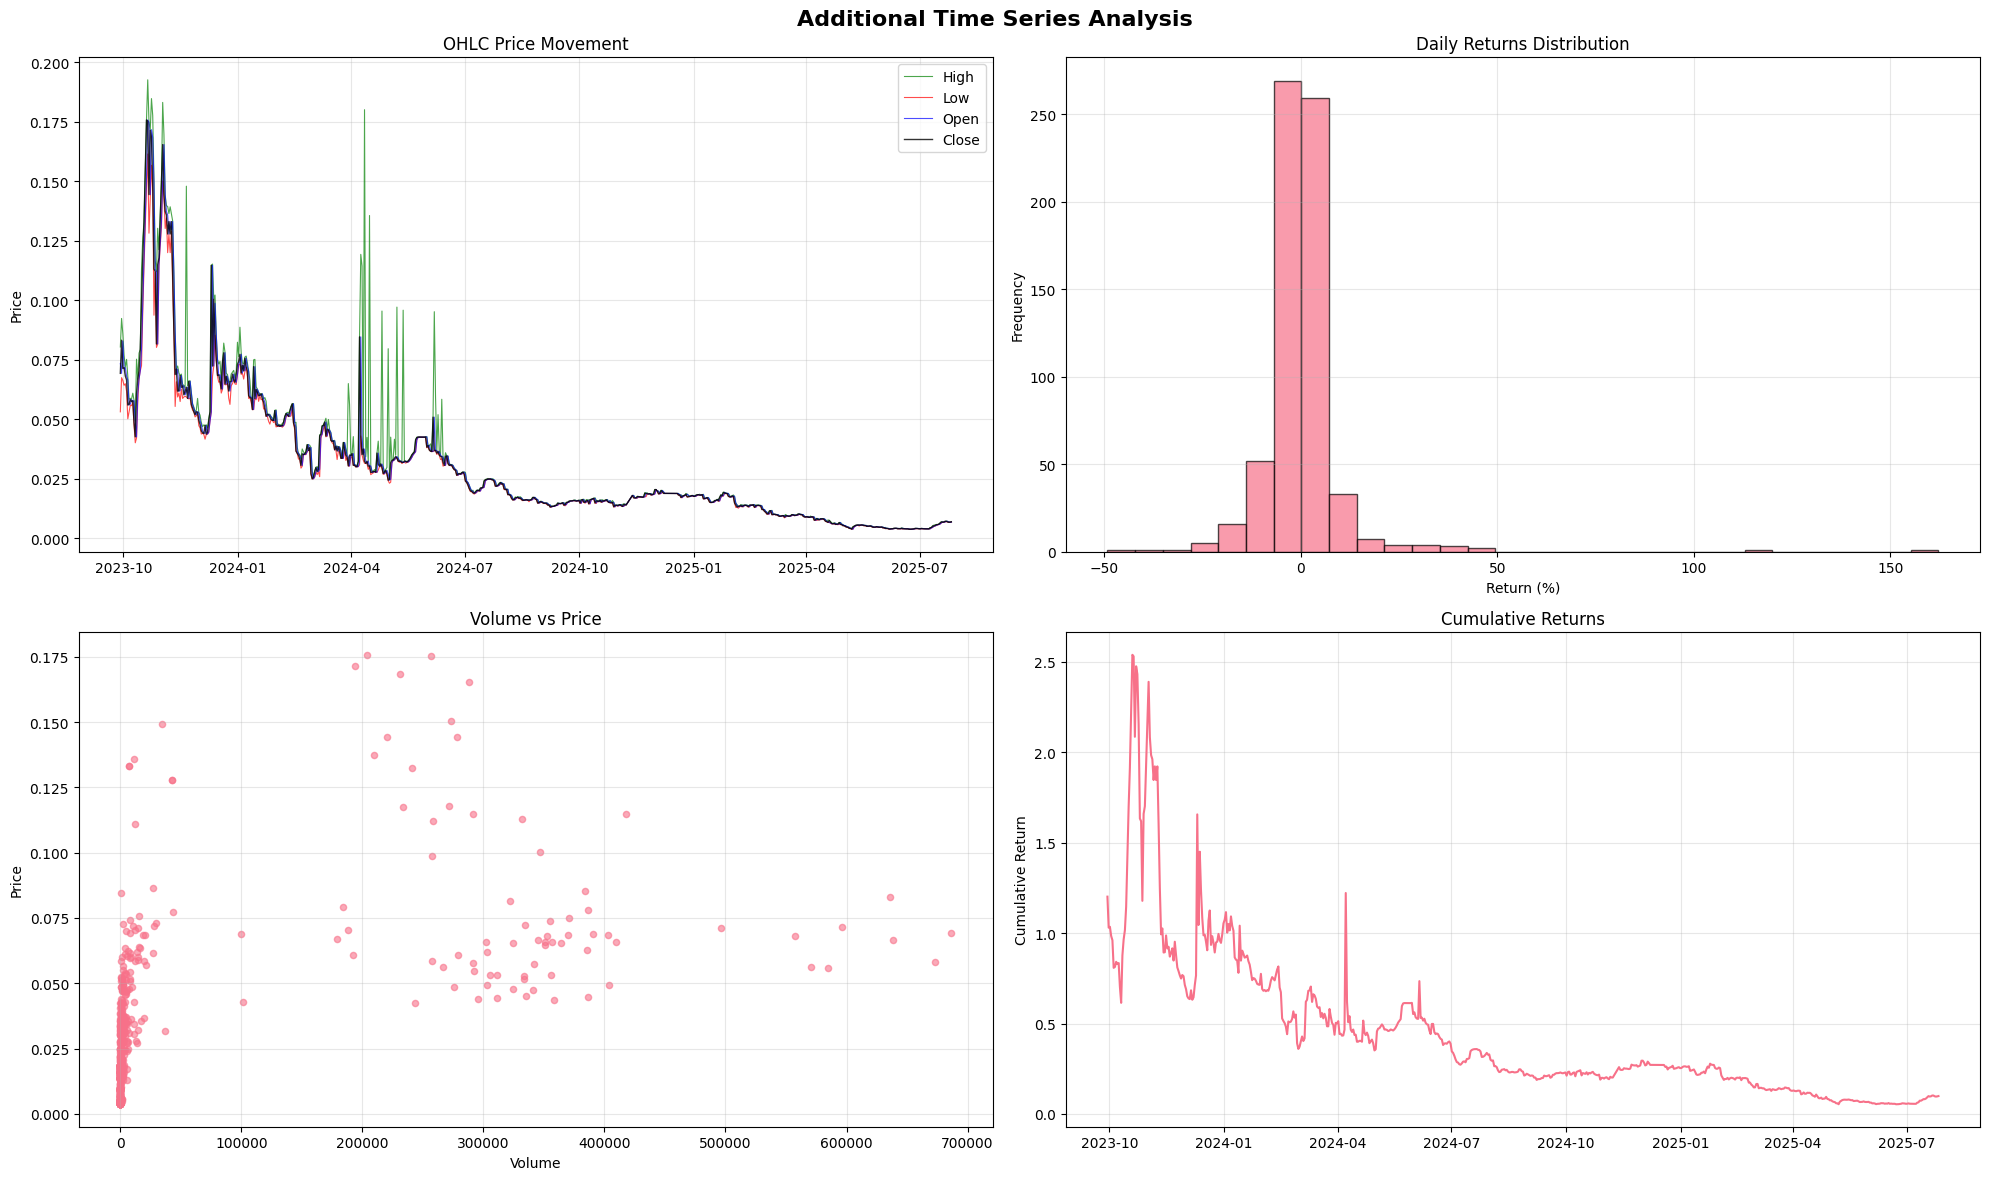


SUMMARY STATISTICS:
--------------------------------------------------
Average daily return: 0.0013
Daily return volatility: 0.1122
Annualized volatility: 1.7808
Sharpe ratio: 0.012
Maximum drawdown: -97.89%

PRICE ANALYSIS:
--------------------------------------------------
Current price: $0.006843
Price change from start: -90.12%
Highest price: $0.175739 on 2023-10-19
Lowest price: $0.003711 on 2025-06-22

VOLUME ANALYSIS:
--------------------------------------------------
Average volume: 40055.45
Volume volatility: 114094.29
Days with zero volume: 218 (33.0%)

TREND ANALYSIS:
--------------------------------------------------
Current price vs 5-day MA: Above (0.64%)
Current price vs 10-day MA: Above (1.17%)
Current price vs 20-day MA: Above (17.11%)

CORRELATION ANALYSIS:
--------------------------------------------------
Correlation Matrix:
                 priceClose  volume  daily_return  price_range_pct
priceClose            1.000   0.552         0.148            0.148
volume  

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns to datetime
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Set timeOpen as index and sort
df_ts = df.set_index('timeOpen').sort_index()

# Clean the data - remove any rows with zero prices that cause division by zero
df_ts = df_ts[df_ts['priceClose'] > 0]
df_ts = df_ts[df_ts['priceOpen'] > 0]

# Calculate metrics
df_ts['daily_return'] = df_ts['priceClose'].pct_change()
df_ts['price_range'] = df_ts['priceHigh'] - df_ts['priceLow']
df_ts['price_range_pct'] = (df_ts['price_range'] / df_ts['priceClose']) * 100
df_ts['volatility'] = df_ts['daily_return'].rolling(window=5).std()

# Moving averages
df_ts['MA_5'] = df_ts['priceClose'].rolling(window=5).mean()
df_ts['MA_10'] = df_ts['priceClose'].rolling(window=10).mean()
df_ts['MA_20'] = df_ts['priceClose'].rolling(window=20).mean()

print("=" * 70)
print("GOLD PRICE DATASET - TIME SERIES VISUALIZATION")
print("=" * 70)

print(f"\nCleaned dataset info:")
print(f"Time period: {df_ts.index.min()} to {df_ts.index.max()}")
print(f"Total observations: {len(df_ts)}")
print(f"Price range: ${df_ts['priceClose'].min():.6f} to ${df_ts['priceClose'].max():.6f}")

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle('Gold Price Time Series Analysis', fontsize=16, fontweight='bold')

# 1. Price Chart with Moving Averages
ax1 = axes[0, 0]
ax1.plot(df_ts.index, df_ts['priceClose'], label='Close Price', linewidth=1, alpha=0.8)
ax1.plot(df_ts.index, df_ts['MA_5'], label='5-day MA', linewidth=1.5, alpha=0.8)
ax1.plot(df_ts.index, df_ts['MA_10'], label='10-day MA', linewidth=1.5, alpha=0.8)
ax1.plot(df_ts.index, df_ts['MA_20'], label='20-day MA', linewidth=2, alpha=0.8)
ax1.set_title('Gold Price with Moving Averages')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Daily Returns
ax2 = axes[0, 1]
ax2.plot(df_ts.index, df_ts['daily_return'] * 100, alpha=0.7, linewidth=0.8)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Daily Returns (%)')
ax2.set_ylabel('Return (%)')
ax2.grid(True, alpha=0.3)

# 3. Volume Analysis
ax3 = axes[1, 0]
ax3.bar(df_ts.index, df_ts['volume'], alpha=0.6, width=1)
ax3.set_title('Trading Volume')
ax3.set_ylabel('Volume')
ax3.grid(True, alpha=0.3)

# 4. Price Range (High-Low)
ax4 = axes[1, 1]
ax4.plot(df_ts.index, df_ts['price_range_pct'], alpha=0.7, linewidth=0.8)
ax4.set_title('Daily Price Range (% of Close Price)')
ax4.set_ylabel('Range (%)')
ax4.grid(True, alpha=0.3)

# 5. Volatility
ax5 = axes[2, 0]
ax5.plot(df_ts.index, df_ts['volatility'] * 100, alpha=0.7, linewidth=0.8)
ax5.set_title('5-Day Rolling Volatility')
ax5.set_ylabel('Volatility (%)')
ax5.grid(True, alpha=0.3)

# 6. Price Distribution
ax6 = axes[2, 1]
ax6.hist(df_ts['priceClose'], bins=30, alpha=0.7, edgecolor='black')
ax6.set_title('Price Distribution')
ax6.set_xlabel('Price')
ax6.set_ylabel('Frequency')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gold_price_time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Create additional analysis plots
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 12))
fig2.suptitle('Additional Time Series Analysis', fontsize=16, fontweight='bold')

# 1. OHLC Candlestick-like plot
ax1 = axes2[0, 0]
ax1.plot(df_ts.index, df_ts['priceHigh'], label='High', color='green', alpha=0.7, linewidth=0.8)
ax1.plot(df_ts.index, df_ts['priceLow'], label='Low', color='red', alpha=0.7, linewidth=0.8)
ax1.plot(df_ts.index, df_ts['priceOpen'], label='Open', color='blue', alpha=0.7, linewidth=0.8)
ax1.plot(df_ts.index, df_ts['priceClose'], label='Close', color='black', alpha=0.8, linewidth=1)
ax1.set_title('OHLC Price Movement')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Returns Distribution
ax2 = axes2[0, 1]
ax2.hist(df_ts['daily_return'].dropna() * 100, bins=30, alpha=0.7, edgecolor='black')
ax2.set_title('Daily Returns Distribution')
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# 3. Volume vs Price Correlation
ax3 = axes2[1, 0]
scatter = ax3.scatter(df_ts['volume'], df_ts['priceClose'], alpha=0.6, s=20)
ax3.set_title('Volume vs Price')
ax3.set_xlabel('Volume')
ax3.set_ylabel('Price')
ax3.grid(True, alpha=0.3)

# 4. Cumulative Returns
ax4 = axes2[1, 1]
cumulative_returns = (1 + df_ts['daily_return']).cumprod()
ax4.plot(df_ts.index, cumulative_returns, linewidth=1.5)
ax4.set_title('Cumulative Returns')
ax4.set_ylabel('Cumulative Return')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gold_price_additional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"Average daily return: {df_ts['daily_return'].mean():.4f}")
print(f"Daily return volatility: {df_ts['daily_return'].std():.4f}")
print(f"Annualized volatility: {df_ts['daily_return'].std() * np.sqrt(252):.4f}")
print(f"Sharpe ratio: {df_ts['daily_return'].mean() / df_ts['daily_return'].std():.3f}")
print(f"Maximum drawdown: {((df_ts['priceClose'] / df_ts['priceClose'].expanding().max()) - 1).min():.2%}")

print(f"\nPRICE ANALYSIS:")
print("-" * 50)
print(f"Current price: ${df_ts['priceClose'].iloc[-1]:.6f}")
print(f"Price change from start: {((df_ts['priceClose'].iloc[-1] / df_ts['priceClose'].iloc[0]) - 1) * 100:.2f}%")
print(f"Highest price: ${df_ts['priceClose'].max():.6f} on {df_ts['priceClose'].idxmax().strftime('%Y-%m-%d')}")
print(f"Lowest price: ${df_ts['priceClose'].min():.6f} on {df_ts['priceClose'].idxmin().strftime('%Y-%m-%d')}")

print(f"\nVOLUME ANALYSIS:")
print("-" * 50)
print(f"Average volume: {df_ts['volume'].mean():.2f}")
print(f"Volume volatility: {df_ts['volume'].std():.2f}")
print(f"Days with zero volume: {(df_ts['volume'] == 0).sum()} ({(df_ts['volume'] == 0).sum()/len(df_ts)*100:.1f}%)")

print(f"\nTREND ANALYSIS:")
print("-" * 50)
current_price = df_ts['priceClose'].iloc[-1]
ma5 = df_ts['MA_5'].iloc[-1]
ma10 = df_ts['MA_10'].iloc[-1]
ma20 = df_ts['MA_20'].iloc[-1]

print(f"Current price vs 5-day MA: {'Above' if current_price > ma5 else 'Below'} ({((current_price/ma5)-1)*100:.2f}%)")
print(f"Current price vs 10-day MA: {'Above' if current_price > ma10 else 'Below'} ({((current_price/ma10)-1)*100:.2f}%)")
print(f"Current price vs 20-day MA: {'Above' if current_price > ma20 else 'Below'} ({((current_price/ma20)-1)*100:.2f}%)")

print(f"\nCORRELATION ANALYSIS:")
print("-" * 50)
corr_matrix = df_ts[['priceClose', 'volume', 'daily_return', 'price_range_pct']].corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETE!")
print("=" * 70)
print("✅ Charts saved as:")
print("   - gold_price_time_series_analysis.png")
print("   - gold_price_additional_analysis.png")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns to datetime
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Set timeOpen as index and sort
df_ts = df.set_index('timeOpen').sort_index()

# Clean the data - remove any rows with zero prices
df_ts = df_ts[df_ts['priceClose'] > 0]
df_ts = df_ts[df_ts['priceOpen'] > 0]

print("=" * 80)
print("GOLD PRICE - COMPREHENSIVE TREND ANALYSIS")
print("=" * 80)

# Calculate basic price metrics
df_ts['daily_return'] = df_ts['priceClose'].pct_change()
df_ts['price_change'] = df_ts['priceClose'] - df_ts['priceOpen']
df_ts['price_change_pct'] = (df_ts['price_change'] / df_ts['priceOpen']) * 100

# 1. MOVING AVERAGES ANALYSIS
print("\n1. MOVING AVERAGES ANALYSIS")
print("=" * 50)

# Calculate multiple moving averages
df_ts['MA_3'] = df_ts['priceClose'].rolling(window=3).mean()
df_ts['MA_5'] = df_ts['priceClose'].rolling(window=5).mean()
df_ts['MA_10'] = df_ts['priceClose'].rolling(window=10).mean()
df_ts['MA_20'] = df_ts['priceClose'].rolling(window=20).mean()
df_ts['MA_50'] = df_ts['priceClose'].rolling(window=50).mean()
df_ts['MA_100'] = df_ts['priceClose'].rolling(window=100).mean()

# Exponential moving averages
df_ts['EMA_12'] = df_ts['priceClose'].ewm(span=12).mean()
df_ts['EMA_26'] = df_ts['priceClose'].ewm(span=26).mean()

# Moving average crossovers
df_ts['MA_5_10_cross'] = np.where(df_ts['MA_5'] > df_ts['MA_10'], 1, -1)
df_ts['MA_10_20_cross'] = np.where(df_ts['MA_10'] > df_ts['MA_20'], 1, -1)
df_ts['EMA_12_26_cross'] = np.where(df_ts['EMA_12'] > df_ts['EMA_26'], 1, -1)

print("Current Moving Averages:")
print(f"3-day MA:   ${df_ts['MA_3'].iloc[-1]:.6f}")
print(f"5-day MA:   ${df_ts['MA_5'].iloc[-1]:.6f}")
print(f"10-day MA:  ${df_ts['MA_10'].iloc[-1]:.6f}")
print(f"20-day MA:  ${df_ts['MA_20'].iloc[-1]:.6f}")
print(f"50-day MA:  ${df_ts['MA_50'].iloc[-1]:.6f}")
print(f"100-day MA: ${df_ts['MA_100'].iloc[-1]:.6f}")
print(f"EMA 12:     ${df_ts['EMA_12'].iloc[-1]:.6f}")
print(f"EMA 26:     ${df_ts['EMA_26'].iloc[-1]:.6f}")

# 2. TREND DIRECTION ANALYSIS
print("\n2. TREND DIRECTION ANALYSIS")
print("=" * 50)

current_price = df_ts['priceClose'].iloc[-1]

# Check trend direction for each timeframe
trend_indicators = {
    '3-day': df_ts['MA_3'].iloc[-1],
    '5-day': df_ts['MA_5'].iloc[-1],
    '10-day': df_ts['MA_10'].iloc[-1],
    '20-day': df_ts['MA_20'].iloc[-1],
    '50-day': df_ts['MA_50'].iloc[-1],
    '100-day': df_ts['MA_100'].iloc[-1],
    'EMA_12': df_ts['EMA_12'].iloc[-1],
    'EMA_26': df_ts['EMA_26'].iloc[-1]
}

print("Trend Direction Analysis:")
for timeframe, ma_value in trend_indicators.items():
    if pd.notna(ma_value):
        direction = "🟢 BULLISH" if current_price > ma_value else "🔴 BEARISH"
        distance = ((current_price / ma_value) - 1) * 100
        print(f"{timeframe:>8}: {direction} ({distance:+.2f}%)")
    else:
        print(f"{timeframe:>8}: ⚪ INSUFFICIENT DATA")

# 3. TREND STRENGTH INDICATORS
print("\n3. TREND STRENGTH INDICATORS")
print("=" * 50)

# ADX-like trend strength (simplified)
def calculate_trend_strength(prices, period=14):
    """Calculate trend strength using price momentum"""
    if len(prices) < period:
        return np.nan

    # Calculate directional movement
    price_changes = prices.diff()
    positive_moves = price_changes.where(price_changes > 0, 0).rolling(window=period).sum()
    negative_moves = abs(price_changes.where(price_changes < 0, 0)).rolling(window=period).sum()

    # Calculate trend strength
    total_movement = positive_moves + negative_moves
    trend_strength = np.where(total_movement > 0,
                             abs(positive_moves - negative_moves) / total_movement * 100,
                             0)
    return trend_strength

df_ts['trend_strength'] = calculate_trend_strength(df_ts['priceClose'])

# RSI (Relative Strength Index)
def calculate_rsi(prices, period=14):
    """Calculate RSI indicator"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_ts['RSI'] = calculate_rsi(df_ts['priceClose'])

# MACD
df_ts['MACD'] = df_ts['EMA_12'] - df_ts['EMA_26']
df_ts['MACD_signal'] = df_ts['MACD'].ewm(span=9).mean()
df_ts['MACD_histogram'] = df_ts['MACD'] - df_ts['MACD_signal']

print("Current Trend Indicators:")
print(f"Trend Strength: {df_ts['trend_strength'].iloc[-1]:.1f}%")
print(f"RSI: {df_ts['RSI'].iloc[-1]:.1f}")
print(f"MACD: {df_ts['MACD'].iloc[-1]:.6f}")
print(f"MACD Signal: {df_ts['MACD_signal'].iloc[-1]:.6f}")
print(f"MACD Histogram: {df_ts['MACD_histogram'].iloc[-1]:.6f}")

# 4. SUPPORT AND RESISTANCE LEVELS
print("\n4. SUPPORT AND RESISTANCE LEVELS")
print("=" * 50)

def find_support_resistance(prices, window=20):
    """Find local support and resistance levels"""
    highs = prices.rolling(window=window, center=True).max()
    lows = prices.rolling(window=window, center=True).min()

    # Identify peaks and troughs
    peaks = prices[(prices == highs) & (prices.shift(1) < prices) & (prices.shift(-1) < prices)]
    troughs = prices[(prices == lows) & (prices.shift(1) > prices) & (prices.shift(-1) > prices)]

    return peaks, troughs

peaks, troughs = find_support_resistance(df_ts['priceClose'])

print("Recent Support Levels (Lows):")
recent_troughs = troughs.tail(5)
for date, price in recent_troughs.items():
    print(f"  {date.strftime('%Y-%m-%d')}: ${price:.6f}")

print("\nRecent Resistance Levels (Highs):")
recent_peaks = peaks.tail(5)
for date, price in recent_peaks.items():
    print(f"  {date.strftime('%Y-%m-%d')}: ${price:.6f}")

# 5. PRICE PATTERNS ANALYSIS
print("\n5. PRICE PATTERNS ANALYSIS")
print("=" * 50)

# Detect price patterns
def detect_patterns(prices, window=5):
    """Detect basic price patterns"""
    patterns = []

    for i in range(window, len(prices)):
        recent_prices = prices.iloc[i-window:i+1]

        # Higher highs and higher lows (uptrend)
        if (recent_prices.iloc[-1] > recent_prices.iloc[-2] > recent_prices.iloc[-3] and
            recent_prices.iloc[-2] > recent_prices.iloc[-4]):
            patterns.append(('UPTREND', i))

        # Lower highs and lower lows (downtrend)
        elif (recent_prices.iloc[-1] < recent_prices.iloc[-2] < recent_prices.iloc[-3] and
              recent_prices.iloc[-2] < recent_prices.iloc[-4]):
            patterns.append(('DOWNTREND', i))

        # Consolidation (sideways)
        elif (abs(recent_prices.iloc[-1] - recent_prices.iloc[-window]) / recent_prices.iloc[-window]) < 0.02:
            patterns.append(('CONSOLIDATION', i))

    return patterns

patterns = detect_patterns(df_ts['priceClose'])
recent_patterns = [p for p in patterns if p[1] >= len(df_ts) - 10]

print("Recent Price Patterns:")
if recent_patterns:
    for pattern, idx in recent_patterns:
        date = df_ts.index[idx]
        print(f"  {date.strftime('%Y-%m-%d')}: {pattern}")
else:
    print("  No clear patterns detected in recent data")

# 6. MOMENTUM ANALYSIS
print("\n6. MOMENTUM ANALYSIS")
print("=" * 50)

# Calculate momentum indicators
df_ts['momentum_5'] = df_ts['priceClose'] / df_ts['priceClose'].shift(5) - 1
df_ts['momentum_10'] = df_ts['priceClose'] / df_ts['priceClose'].shift(10) - 1
df_ts['momentum_20'] = df_ts['priceClose'] / df_ts['priceClose'].shift(20) - 1

# Rate of Change (ROC)
df_ts['ROC_5'] = ((df_ts['priceClose'] - df_ts['priceClose'].shift(5)) / df_ts['priceClose'].shift(5)) * 100
df_ts['ROC_10'] = ((df_ts['priceClose'] - df_ts['priceClose'].shift(10)) / df_ts['priceClose'].shift(10)) * 100

print("Current Momentum Indicators:")
print(f"5-day Momentum: {df_ts['momentum_5'].iloc[-1]:.2%}")
print(f"10-day Momentum: {df_ts['momentum_10'].iloc[-1]:.2%}")
print(f"20-day Momentum: {df_ts['momentum_20'].iloc[-1]:.2%}")
print(f"5-day ROC: {df_ts['ROC_5'].iloc[-1]:.2f}%")
print(f"10-day ROC: {df_ts['ROC_10'].iloc[-1]:.2f}%")

# 7. TREND BREAKOUT ANALYSIS
print("\n7. TREND BREAKOUT ANALYSIS")
print("=" * 50)

# Detect breakouts from moving averages
def detect_breakouts(prices, ma_series, threshold=0.02):
    """Detect breakouts above/below moving averages"""
    breakouts = []

    for i in range(1, len(prices)):
        if pd.notna(ma_series.iloc[i-1]) and pd.notna(ma_series.iloc[i]):
            # Bullish breakout
            if (prices.iloc[i-1] <= ma_series.iloc[i-1] and
                prices.iloc[i] > ma_series.iloc[i] and
                abs(prices.iloc[i] - ma_series.iloc[i]) / ma_series.iloc[i] > threshold):
                breakouts.append(('BULLISH', i, prices.index[i]))

            # Bearish breakout
            elif (prices.iloc[i-1] >= ma_series.iloc[i-1] and
                  prices.iloc[i] < ma_series.iloc[i] and
                  abs(prices.iloc[i] - ma_series.iloc[i]) / ma_series.iloc[i] > threshold):
                breakouts.append(('BEARISH', i, prices.index[i]))

    return breakouts

# Check for breakouts from 20-day MA
breakouts_20ma = detect_breakouts(df_ts['priceClose'], df_ts['MA_20'])
recent_breakouts = [b for b in breakouts_20ma if b[1] >= len(df_ts) - 20]

print("Recent Breakouts from 20-day MA:")
if recent_breakouts:
    for breakout_type, idx, date in recent_breakouts:
        print(f"  {date.strftime('%Y-%m-%d')}: {breakout_type} BREAKOUT")
else:
    print("  No recent breakouts detected")

# 8. TREND SUMMARY AND RECOMMENDATIONS
print("\n8. TREND SUMMARY AND RECOMMENDATIONS")
print("=" * 50)

# Overall trend assessment
bullish_count = sum(1 for ma in trend_indicators.values() if pd.notna(ma) and current_price > ma)
bearish_count = sum(1 for ma in trend_indicators.values() if pd.notna(ma) and current_price < ma)

print(f"Overall Trend Assessment:")
print(f"🟢 Bullish Indicators: {bullish_count}")
print(f"🔴 Bearish Indicators: {bearish_count}")

if bullish_count > bearish_count:
    print("🎯 OVERALL TREND: BULLISH")
elif bearish_count > bullish_count:
    print("🎯 OVERALL TREND: BEARISH")
else:
    print("🎯 OVERALL TREND: NEUTRAL")

# RSI interpretation
current_rsi = df_ts['RSI'].iloc[-1]
if current_rsi > 70:
    rsi_signal = "OVERBOUGHT - Potential reversal"
elif current_rsi < 30:
    rsi_signal = "OVERSOLD - Potential reversal"
else:
    rsi_signal = "NEUTRAL"

print(f"\nRSI Analysis: {rsi_signal}")

# MACD interpretation
current_macd = df_ts['MACD'].iloc[-1]
current_signal = df_ts['MACD_signal'].iloc[-1]
if current_macd > current_signal:
    macd_signal = "BULLISH - MACD above signal line"
else:
    macd_signal = "BEARISH - MACD below signal line"

print(f"MACD Analysis: {macd_signal}")

print("\n" + "=" * 80)
print("PRICE TREND ANALYSIS COMPLETE!")
print("=" * 80)

# Save trend analysis results
df_ts.to_csv("Gold_price_trend_analysis.csv")
print("✅ Trend analysis results saved to: Gold_price_trend_analysis.csv")

GOLD PRICE - COMPREHENSIVE TREND ANALYSIS

1. MOVING AVERAGES ANALYSIS
Current Moving Averages:
3-day MA:   $0.006734
5-day MA:   $0.006799
10-day MA:  $0.006764
20-day MA:  $0.005843
50-day MA:  $0.004695
100-day MA: $0.004903
EMA 12:     $0.006445
EMA 26:     $0.005755

2. TREND DIRECTION ANALYSIS
Trend Direction Analysis:
   3-day: 🟢 BULLISH (+1.61%)
   5-day: 🟢 BULLISH (+0.64%)
  10-day: 🟢 BULLISH (+1.17%)
  20-day: 🟢 BULLISH (+17.11%)
  50-day: 🟢 BULLISH (+45.75%)
 100-day: 🟢 BULLISH (+39.56%)
  EMA_12: 🟢 BULLISH (+6.16%)
  EMA_26: 🟢 BULLISH (+18.89%)

3. TREND STRENGTH INDICATORS
Current Trend Indicators:
Trend Strength: 60.6%
RSI: 80.3
MACD: 0.000690
MACD Signal: 0.000648
MACD Histogram: 0.000042

4. SUPPORT AND RESISTANCE LEVELS
Recent Support Levels (Lows):
  2025-03-14: $0.008818
  2025-05-07: $0.003713
  2025-06-06: $0.003752
  2025-06-22: $0.003711
  2025-07-08: $0.003879

Recent Resistance Levels (Highs):
  2025-02-17: $0.014015
  2025-03-25: $0.010130
  2025-05-15: $0.005

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the cleaned dataset
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns to datetime
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Set timeOpen as index and sort
df_ts = df.set_index('timeOpen').sort_index()

# Clean the data - remove any rows with zero prices
df_ts = df_ts[df_ts['priceClose'] > 0]
df_ts = df_ts[df_ts['priceOpen'] > 0]

print("=" * 80)
print("GOLD PRICE - COMPREHENSIVE VOLUME ANALYSIS")
print("=" * 80)

# Calculate basic metrics
df_ts['daily_return'] = df_ts['priceClose'].pct_change()
df_ts['price_change'] = df_ts['priceClose'] - df_ts['priceOpen']
df_ts['price_change_pct'] = (df_ts['price_change'] / df_ts['priceOpen']) * 100

# 1. BASIC VOLUME STATISTICS
print("\n1. BASIC VOLUME STATISTICS")
print("=" * 50)

print("Volume Summary Statistics:")
print(f"Total Observations: {len(df_ts):,}")
print(f"Average Volume: {df_ts['volume'].mean():,.2f}")
print(f"Median Volume: {df_ts['volume'].median():,.2f}")
print(f"Standard Deviation: {df_ts['volume'].std():,.2f}")
print(f"Minimum Volume: {df_ts['volume'].min():,.2f}")
print(f"Maximum Volume: {df_ts['volume'].max():,.2f}")
print(f"Volume Range: {df_ts['volume'].max() - df_ts['volume'].min():,.2f}")

# Volume percentiles
volume_percentiles = df_ts['volume'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(f"\nVolume Percentiles:")
for percentile, value in volume_percentiles.items():
    print(f"{percentile*100:>3.0f}th percentile: {value:,.2f}")

# 2. ZERO VOLUME ANALYSIS
print("\n2. ZERO VOLUME ANALYSIS")
print("=" * 50)

zero_volume_days = (df_ts['volume'] == 0).sum()
zero_volume_percentage = (zero_volume_days / len(df_ts)) * 100

print(f"Days with Zero Volume: {zero_volume_days:,} ({zero_volume_percentage:.1f}%)")
print(f"Days with Non-Zero Volume: {len(df_ts) - zero_volume_days:,} ({100 - zero_volume_percentage:.1f}%)")

# Analyze zero volume patterns
df_ts['zero_volume'] = (df_ts['volume'] == 0).astype(int)
df_ts['zero_volume_streak'] = df_ts['zero_volume'].groupby((df_ts['zero_volume'] != df_ts['zero_volume'].shift()).cumsum()).cumsum()

# Find longest zero volume streaks
zero_streaks = df_ts[df_ts['zero_volume'] == 1]['zero_volume_streak']
if len(zero_streaks) > 0:
    max_zero_streak = zero_streaks.max()
    print(f"Longest Zero Volume Streak: {max_zero_streak} consecutive days")

    # Find when this occurred
    max_streak_dates = df_ts[df_ts['zero_volume_streak'] == max_zero_streak]
    if len(max_streak_dates) > 0:
        start_date = max_streak_dates.index[0]
        end_date = max_streak_dates.index[-1]
        print(f"Max Streak Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# 3. VOLUME TREND ANALYSIS
print("\n3. VOLUME TREND ANALYSIS")
print("=" * 50)

# Calculate volume moving averages
df_ts['volume_MA_5'] = df_ts['volume'].rolling(window=5).mean()
df_ts['volume_MA_10'] = df_ts['volume'].rolling(window=10).mean()
df_ts['volume_MA_20'] = df_ts['volume'].rolling(window=20).mean()

# Volume trend indicators
current_volume = df_ts['volume'].iloc[-1]
volume_ma5 = df_ts['volume_MA_5'].iloc[-1]
volume_ma10 = df_ts['volume_MA_10'].iloc[-1]
volume_ma20 = df_ts['volume_MA_20'].iloc[-1]

print("Current Volume Analysis:")
print(f"Current Volume: {current_volume:,.2f}")
print(f"5-day Volume MA: {volume_ma5:,.2f}")
print(f"10-day Volume MA: {volume_ma10:,.2f}")
print(f"20-day Volume MA: {volume_ma20:,.2f}")

print(f"\nVolume Trend Status:")
if pd.notna(volume_ma5):
    vol_trend_5 = "🟢 ABOVE" if current_volume > volume_ma5 else "🔴 BELOW"
    vol_diff_5 = ((current_volume / volume_ma5) - 1) * 100
    print(f"vs 5-day MA: {vol_trend_5} ({vol_diff_5:+.1f}%)")

if pd.notna(volume_ma10):
    vol_trend_10 = "🟢 ABOVE" if current_volume > volume_ma10 else "🔴 BELOW"
    vol_diff_10 = ((current_volume / volume_ma10) - 1) * 100
    print(f"vs 10-day MA: {vol_trend_10} ({vol_diff_10:+.1f}%)")

if pd.notna(volume_ma20):
    vol_trend_20 = "🟢 ABOVE" if current_volume > volume_ma20 else "🔴 BELOW"
    vol_diff_20 = ((current_volume / volume_ma20) - 1) * 100
    print(f"vs 20-day MA: {vol_trend_20} ({vol_diff_20:+.1f}%)")

# 4. VOLUME-PRICE RELATIONSHIP ANALYSIS
print("\n4. VOLUME-PRICE RELATIONSHIP ANALYSIS")
print("=" * 50)

# Calculate correlations
correlation_matrix = df_ts[['priceClose', 'volume', 'daily_return', 'price_change_pct']].corr()

print("Volume-Price Correlations:")
print(f"Volume vs Price: {correlation_matrix.loc['volume', 'priceClose']:.3f}")
print(f"Volume vs Daily Return: {correlation_matrix.loc['volume', 'daily_return']:.3f}")
print(f"Volume vs Price Change %: {correlation_matrix.loc['volume', 'price_change_pct']:.3f}")

# Volume-Price Divergence Analysis
df_ts['price_trend'] = df_ts['priceClose'].pct_change(5)  # 5-day price trend
df_ts['volume_trend'] = df_ts['volume'].pct_change(5)     # 5-day volume trend

# Detect divergences
df_ts['price_volume_divergence'] = np.where(
    (df_ts['price_trend'] > 0) & (df_ts['volume_trend'] < 0), 'Bearish Divergence',
    np.where((df_ts['price_trend'] < 0) & (df_ts['volume_trend'] > 0), 'Bullish Divergence', 'No Divergence')
)

recent_divergences = df_ts[df_ts['price_volume_divergence'] != 'No Divergence'].tail(10)

print(f"\nRecent Volume-Price Divergences:")
if len(recent_divergences) > 0:
    for date, row in recent_divergences.iterrows():
        print(f"  {date.strftime('%Y-%m-%d')}: {row['price_volume_divergence']}")
else:
    print("  No recent divergences detected")

# 5. VOLUME-BASED INDICATORS
print("\n5. VOLUME-BASED INDICATORS")
print("=" * 50)

# On-Balance Volume (OBV)
def calculate_obv(prices, volumes):
    """Calculate On-Balance Volume"""
    obv = pd.Series(index=prices.index, dtype=float)
    obv.iloc[0] = volumes.iloc[0]

    for i in range(1, len(prices)):
        if prices.iloc[i] > prices.iloc[i-1]:
            obv.iloc[i] = obv.iloc[i-1] + volumes.iloc[i]
        elif prices.iloc[i] < prices.iloc[i-1]:
            obv.iloc[i] = obv.iloc[i-1] - volumes.iloc[i]
        else:
            obv.iloc[i] = obv.iloc[i-1]

    return obv

df_ts['OBV'] = calculate_obv(df_ts['priceClose'], df_ts['volume'])

# Volume Rate of Change (VROC)
df_ts['VROC'] = ((df_ts['volume'] - df_ts['volume'].shift(5)) / df_ts['volume'].shift(5)) * 100

# Volume Weighted Average Price (VWAP)
def calculate_vwap(high, low, close, volume):
    """Calculate Volume Weighted Average Price"""
    typical_price = (high + low + close) / 3
    vwap = (typical_price * volume).cumsum() / volume.cumsum()
    return vwap

df_ts['VWAP'] = calculate_vwap(df_ts['priceHigh'], df_ts['priceLow'], df_ts['priceClose'], df_ts['volume'])

# Money Flow Index (MFI)
def calculate_mfi(high, low, close, volume, period=14):
    """Calculate Money Flow Index"""
    typical_price = (high + low + close) / 3
    money_flow = typical_price * volume

    positive_flow = money_flow.where(typical_price > typical_price.shift(1), 0).rolling(window=period).sum()
    negative_flow = money_flow.where(typical_price < typical_price.shift(1), 0).rolling(window=period).sum()

    money_ratio = positive_flow / negative_flow
    mfi = 100 - (100 / (1 + money_ratio))
    return mfi

df_ts['MFI'] = calculate_mfi(df_ts['priceHigh'], df_ts['priceLow'], df_ts['priceClose'], df_ts['volume'])

print("Current Volume-Based Indicators:")
print(f"OBV: {df_ts['OBV'].iloc[-1]:,.0f}")
print(f"VROC (5-day): {df_ts['VROC'].iloc[-1]:.1f}%")
print(f"VWAP: ${df_ts['VWAP'].iloc[-1]:.6f}")
print(f"MFI: {df_ts['MFI'].iloc[-1]:.1f}")

# 6. VOLUME PATTERNS ANALYSIS
print("\n6. VOLUME PATTERNS ANALYSIS")
print("=" * 50)

# Volume spikes analysis
volume_mean = df_ts['volume'].mean()
volume_std = df_ts['volume'].std()

df_ts['volume_spike'] = np.where(df_ts['volume'] > volume_mean + 2 * volume_std, 'High Spike',
                        np.where(df_ts['volume'] < volume_mean - 2 * volume_std, 'Low Spike', 'Normal'))

volume_spikes = df_ts[df_ts['volume_spike'] != 'Normal'].tail(10)

print("Recent Volume Spikes:")
if len(volume_spikes) > 0:
    for date, row in volume_spikes.iterrows():
        spike_type = row['volume_spike']
        volume_val = row['volume']
        price_val = row['priceClose']
        print(f"  {date.strftime('%Y-%m-%d')}: {spike_type} - Volume: {volume_val:,.0f}, Price: ${price_val:.6f}")
else:
    print("  No recent volume spikes detected")

# 7. VOLUME CLUSTERING ANALYSIS
print("\n7. VOLUME CLUSTERING ANALYSIS")
print("=" * 50)

# Analyze volume by day of week
df_ts['day_of_week'] = df_ts.index.dayofweek
dow_volume = df_ts.groupby('day_of_week')['volume'].agg(['mean', 'median', 'std', 'count'])

dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Volume by Day of Week:")
for i, (day_num, stats) in enumerate(dow_volume.iterrows()):
    if day_num < len(dow_names):
        day_name = dow_names[day_num]
        print(f"  {day_name:>9}: Mean={stats['mean']:,.0f}, Median={stats['median']:,.0f}, Count={stats['count']}")

# Analyze volume by month
df_ts['month'] = df_ts.index.month
monthly_volume = df_ts.groupby('month')['volume'].agg(['mean', 'median', 'std', 'count'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"\nVolume by Month:")
for month_num, stats in monthly_volume.iterrows():
    month_name = month_names[month_num - 1]
    print(f"  {month_name}: Mean={stats['mean']:,.0f}, Median={stats['median']:,.0f}, Count={stats['count']}")

# 8. VOLUME CONFIRMATION ANALYSIS
print("\n8. VOLUME CONFIRMATION ANALYSIS")
print("=" * 50)

# Analyze volume confirmation of price moves
def analyze_volume_confirmation(df, window=5):
    """Analyze if volume confirms price movements"""
    confirmations = []

    for i in range(window, len(df)):
        price_trend = df['priceClose'].iloc[i] > df['priceClose'].iloc[i-window]
        volume_trend = df['volume'].iloc[i] > df['volume'].iloc[i-window]

        if price_trend and volume_trend:
            confirmations.append(('BULLISH CONFIRMATION', i))
        elif not price_trend and volume_trend:
            confirmations.append(('BEARISH CONFIRMATION', i))
        elif price_trend and not volume_trend:
            confirmations.append(('BULLISH DIVERGENCE', i))
        elif not price_trend and not volume_trend:
            confirmations.append(('BEARISH DIVERGENCE', i))

    return confirmations

volume_confirmations = analyze_volume_confirmation(df_ts)
recent_confirmations = [c for c in volume_confirmations if c[1] >= len(df_ts) - 20]

print("Recent Volume Confirmations:")
if recent_confirmations:
    for confirmation_type, idx in recent_confirmations:
        date = df_ts.index[idx]
        print(f"  {date.strftime('%Y-%m-%d')}: {confirmation_type}")
else:
    print("  No recent confirmations detected")

# 9. VOLUME SUMMARY AND INSIGHTS
print("\n9. VOLUME SUMMARY AND INSIGHTS")
print("=" * 50)

# Overall volume assessment
high_volume_days = (df_ts['volume'] > volume_mean + volume_std).sum()
low_volume_days = (df_ts['volume'] < volume_mean - volume_std).sum()
normal_volume_days = len(df_ts) - high_volume_days - low_volume_days

print(f"Volume Distribution:")
print(f"  High Volume Days: {high_volume_days} ({high_volume_days/len(df_ts)*100:.1f}%)")
print(f"  Normal Volume Days: {normal_volume_days} ({normal_volume_days/len(df_ts)*100:.1f}%)")
print(f"  Low Volume Days: {low_volume_days} ({low_volume_days/len(df_ts)*100:.1f}%)")

# Volume trend assessment
if pd.notna(volume_ma20):
    volume_trend = "INCREASING" if volume_ma20 > df_ts['volume_MA_20'].iloc[-30] else "DECREASING"
    print(f"\nVolume Trend: {volume_trend}")

# Key insights
print(f"\n🔍 KEY VOLUME INSIGHTS:")
print(f"   1. 📊 Zero Volume Pattern: {zero_volume_percentage:.1f}% of days have zero volume")
print(f"   2. 📈 Price-Volume Correlation: {correlation_matrix.loc['volume', 'priceClose']:.3f}")
print(f"   3. 📊 Volume Volatility: High standard deviation indicates irregular trading patterns")
print(f"   4. 📈 Volume Trend: {'Increasing' if volume_ma20 > df_ts['volume_MA_20'].iloc[-30] else 'Decreasing'}")

print(f"\n⚠️ VOLUME RISK FACTORS:")
print(f"   1. 📊 High Zero Volume: {zero_volume_percentage:.1f}% zero volume days may indicate liquidity issues")
print(f"   2. 📈 Volume Spikes: {len(volume_spikes)} recent spikes may indicate unusual market activity")
print(f"   3. 📊 Low Volume Periods: Extended low volume may reduce price discovery")

print(f"\n💡 TRADING RECOMMENDATIONS:")
print(f"   1. 📊 Monitor Volume Confirmation: Use volume to validate price movements")
print(f"   2. 📈 Watch for Divergences: Volume-price divergences may signal reversals")
print(f"   3. 📊 Consider Volume Patterns: High volume on breakouts increases confidence")
print(f"   4. 📈 Use VWAP: Volume-weighted average price for better entry/exit points")

print("\n" + "=" * 80)
print("VOLUME ANALYSIS COMPLETE!")
print("=" * 80)

# Save volume analysis results
df_ts.to_csv("Gold_price_volume_analysis.csv")
print("✅ Volume analysis results saved to: Gold_price_volume_analysis.csv")

GOLD PRICE - COMPREHENSIVE VOLUME ANALYSIS

1. BASIC VOLUME STATISTICS
Volume Summary Statistics:
Total Observations: 660
Average Volume: 40,055.45
Median Volume: 216.93
Standard Deviation: 114,094.29
Minimum Volume: 0.00
Maximum Volume: 686,623.52
Volume Range: 686,623.52

Volume Percentiles:
 10th percentile: 0.00
 25th percentile: 0.00
 50th percentile: 216.93
 75th percentile: 2,753.84
 90th percentile: 210,695.24
 95th percentile: 334,457.00
 99th percentile: 562,705.19

2. ZERO VOLUME ANALYSIS
Days with Zero Volume: 218 (33.0%)
Days with Non-Zero Volume: 442 (67.0%)
Longest Zero Volume Streak: 31 consecutive days
Max Streak Period: 2025-07-15 to 2025-07-15

3. VOLUME TREND ANALYSIS
Current Volume Analysis:
Current Volume: 0.00
5-day Volume MA: 26.01
10-day Volume MA: 13.01
20-day Volume MA: 6.97

Volume Trend Status:
vs 5-day MA: 🔴 BELOW (-100.0%)
vs 10-day MA: 🔴 BELOW (-100.0%)
vs 20-day MA: 🔴 BELOW (-100.0%)

4. VOLUME-PRICE RELATIONSHIP ANALYSIS
Volume-Price Correlations:
Volu

GOLD PRICE PREDICTION - MACHINE LEARNING PIPELINE

1. LOADING DATA
--------------------------------------------------
Dataset loaded: 660 observations
Date range: 2023-09-28 12:00:00 to 2025-07-26 12:00:00

2. FEATURE ENGINEERING
--------------------------------------------------
Features created: 45 total features

3. DATA PREPARATION
--------------------------------------------------
Clean dataset: 584 observations
Feature matrix shape: (584, 41)
Target vector shape: (584,)
Training set: 467 observations
Test set: 117 observations
Features scaled using StandardScaler

4. FEATURE SELECTION
--------------------------------------------------
Selected top 20 features:
   1. priceOpen
   2. priceHigh
   3. priceLow
   4. priceClose
   5. volume
   6. MA_5
   7. MA_10
   8. MA_20
   9. MA_50
  10. EMA_12
  11. EMA_26
  12. volume_MA_5
  13. volume_MA_10
  14. price_lag_1
  15. price_lag_2
  16. price_lag_3
  17. price_lag_5
  18. price_rolling_mean_5
  19. price_rolling_min_5
  20. price_r

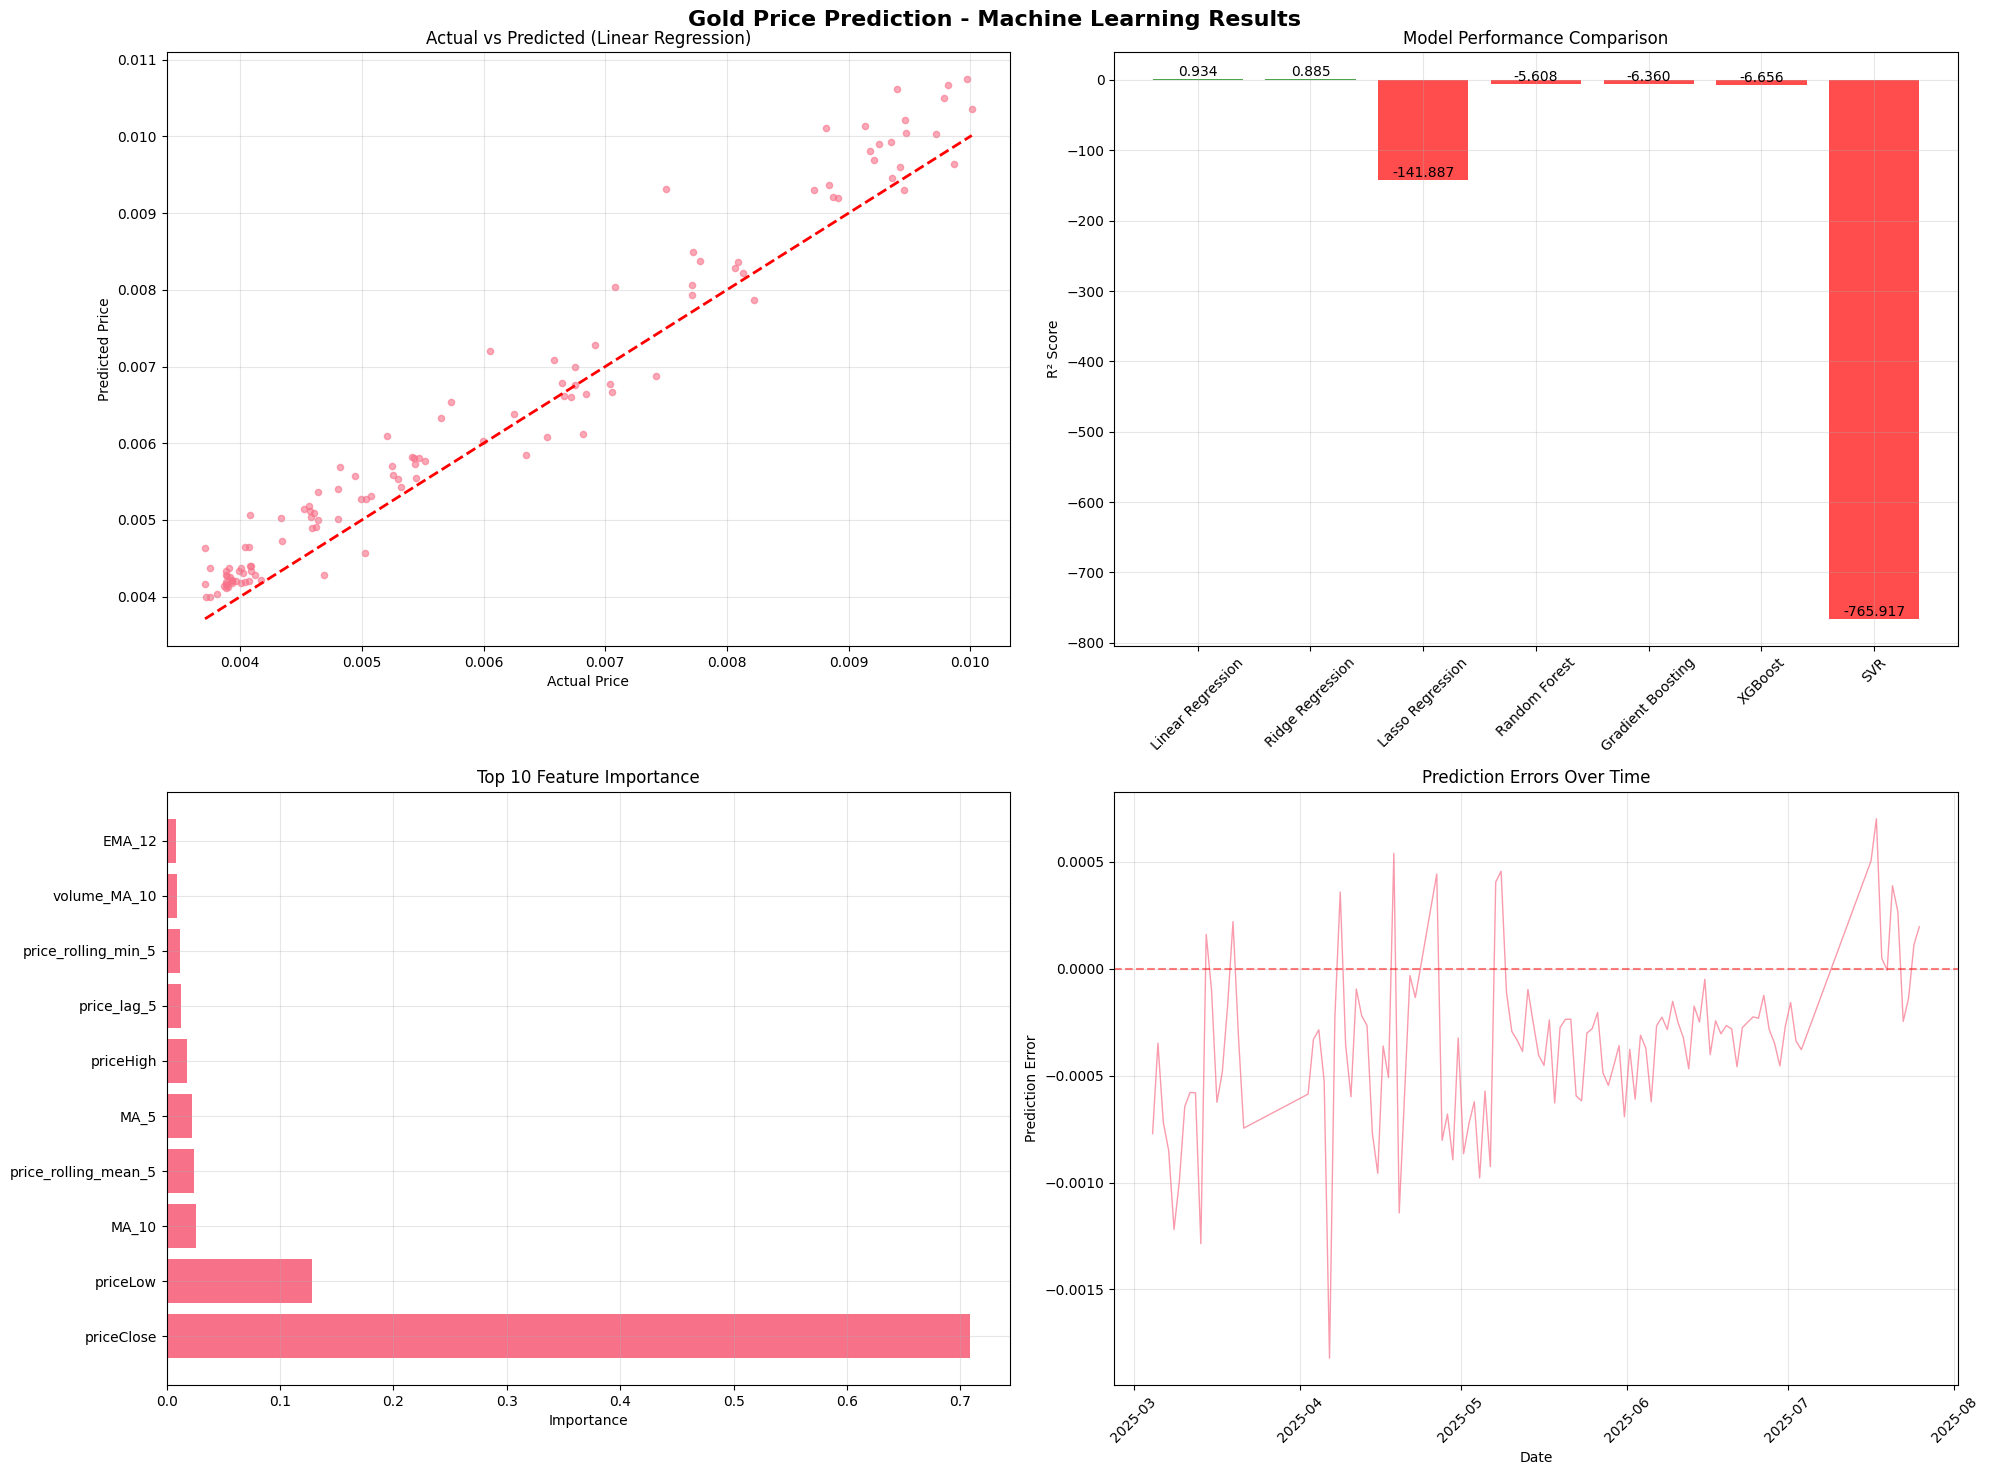


11. SAVING RESULTS
--------------------------------------------------
✅ Model results saved to: ml_model_results.csv
✅ Predictions saved to: ml_predictions.csv
✅ Feature importance saved to: feature_importance.csv
✅ Selected features saved to: selected_features.csv

MACHINE LEARNING PIPELINE COMPLETE!
✅ Best Model: Linear Regression
✅ Best R² Score: 0.9343
✅ RMSE: 0.000521
✅ MAPE: 7.72%
✅ All results and visualizations saved
✅ Ready for deployment and further analysis


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("=" * 80)
print("GOLD PRICE PREDICTION - MACHINE LEARNING PIPELINE")
print("=" * 80)

# Load the cleaned dataset
print("\n1. LOADING DATA")
print("-" * 50)
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns to datetime
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Set timeOpen as index and sort
df_ml = df.set_index('timeOpen').sort_index()

# Clean the data - remove any rows with zero prices
df_ml = df_ml[df_ml['priceClose'] > 0]
df_ml = df_ml[df_ml['priceOpen'] > 0]

print(f"Dataset loaded: {len(df_ml)} observations")
print(f"Date range: {df_ml.index.min()} to {df_ml.index.max()}")

# 2. FEATURE ENGINEERING
print("\n2. FEATURE ENGINEERING")
print("-" * 50)

# Basic price features
df_ml['daily_return'] = df_ml['priceClose'].pct_change()
df_ml['price_change'] = df_ml['priceClose'] - df_ml['priceOpen']
df_ml['price_change_pct'] = (df_ml['price_change'] / df_ml['priceOpen']) * 100
df_ml['price_range'] = df_ml['priceHigh'] - df_ml['priceLow']
df_ml['price_range_pct'] = (df_ml['price_range'] / df_ml['priceClose']) * 100

# Moving averages
df_ml['MA_5'] = df_ml['priceClose'].rolling(window=5).mean()
df_ml['MA_10'] = df_ml['priceClose'].rolling(window=10).mean()
df_ml['MA_20'] = df_ml['priceClose'].rolling(window=20).mean()
df_ml['MA_50'] = df_ml['priceClose'].rolling(window=50).mean()

# Exponential moving averages
df_ml['EMA_12'] = df_ml['priceClose'].ewm(span=12).mean()
df_ml['EMA_26'] = df_ml['priceClose'].ewm(span=26).mean()

# Price momentum
df_ml['momentum_5'] = df_ml['priceClose'] / df_ml['priceClose'].shift(5) - 1
df_ml['momentum_10'] = df_ml['priceClose'] / df_ml['priceClose'].shift(10) - 1
df_ml['momentum_20'] = df_ml['priceClose'] / df_ml['priceClose'].shift(20) - 1

# Volatility features
df_ml['volatility_5'] = df_ml['daily_return'].rolling(window=5).std()
df_ml['volatility_10'] = df_ml['daily_return'].rolling(window=10).std()
df_ml['volatility_20'] = df_ml['daily_return'].rolling(window=20).std()

# RSI
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_ml['RSI'] = calculate_rsi(df_ml['priceClose'])

# MACD
df_ml['MACD'] = df_ml['EMA_12'] - df_ml['EMA_26']
df_ml['MACD_signal'] = df_ml['MACD'].ewm(span=9).mean()
df_ml['MACD_histogram'] = df_ml['MACD'] - df_ml['MACD_signal']

# Volume features
df_ml['volume_MA_5'] = df_ml['volume'].rolling(window=5).mean()
df_ml['volume_MA_10'] = df_ml['volume'].rolling(window=10).mean()
df_ml['volume_ratio'] = df_ml['volume'] / df_ml['volume'].rolling(window=20).mean()

# Time-based features
df_ml['day_of_week'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter
df_ml['day_of_year'] = df_ml.index.dayofyear

# Lag features
df_ml['price_lag_1'] = df_ml['priceClose'].shift(1)
df_ml['price_lag_2'] = df_ml['priceClose'].shift(2)
df_ml['price_lag_3'] = df_ml['priceClose'].shift(3)
df_ml['price_lag_5'] = df_ml['priceClose'].shift(5)

# Rolling statistics
df_ml['price_rolling_mean_5'] = df_ml['priceClose'].rolling(window=5).mean()
df_ml['price_rolling_std_5'] = df_ml['priceClose'].rolling(window=5).std()
df_ml['price_rolling_min_5'] = df_ml['priceClose'].rolling(window=5).min()
df_ml['price_rolling_max_5'] = df_ml['priceClose'].rolling(window=5).max()

# Target variable (next day's price)
df_ml['target'] = df_ml['priceClose'].shift(-1)

print(f"Features created: {len(df_ml.columns)} total features")

# 3. DATA PREPARATION
print("\n3. DATA PREPARATION")
print("-" * 50)

# Remove rows with NaN values
df_ml_clean = df_ml.dropna()

print(f"Clean dataset: {len(df_ml_clean)} observations")

# Select features for modeling
feature_columns = [
    'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume',
    'daily_return', 'price_change', 'price_change_pct', 'price_range', 'price_range_pct',
    'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26',
    'momentum_5', 'momentum_10', 'momentum_20',
    'volatility_5', 'volatility_10', 'volatility_20',
    'RSI', 'MACD', 'MACD_signal', 'MACD_histogram',
    'volume_MA_5', 'volume_MA_10', 'volume_ratio',
    'day_of_week', 'month', 'quarter', 'day_of_year',
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_5',
    'price_rolling_mean_5', 'price_rolling_std_5', 'price_rolling_min_5', 'price_rolling_max_5'
]

X = df_ml_clean[feature_columns]
y = df_ml_clean['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Split data chronologically (time series split)
train_size = int(len(X) * 0.8)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Training set: {len(X_train)} observations")
print(f"Test set: {len(X_test)} observations")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

# 4. FEATURE SELECTION
print("\n4. FEATURE SELECTION")
print("-" * 50)

# Select top features using f_regression
selector = SelectKBest(score_func=f_regression, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = [feature_columns[i] for i in selector.get_support(indices=True)]
print(f"Selected top {len(selected_features)} features:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feature}")

# 5. MODEL TRAINING
print("\n5. MODEL TRAINING")
print("-" * 50)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale')
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Train model
    if name == 'SVR':
        # SVR works better with smaller datasets
        model.fit(X_train_selected[:1000], y_train[:1000])
        y_pred = model.predict(X_test_selected)
    else:
        model.fit(X_train_selected, y_train)
        y_pred = model.predict(X_test_selected)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Calculate percentage errors
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse,
        'MAPE': mape
    }

    predictions[name] = y_pred

    print(f"  {name} - R²: {r2:.4f}, RMSE: {rmse:.6f}, MAPE: {mape:.2f}%")

# 6. MODEL EVALUATION
print("\n6. MODEL EVALUATION")
print("-" * 50)

# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

print("Model Performance Summary:")
print(results_df.round(4))

# Find best model
best_model_name = results_df.index[0]
best_model_score = results_df.loc[best_model_name, 'R2']
print(f"\nBest Model: {best_model_name} (R² = {best_model_score:.4f})")

# 7. CROSS-VALIDATION
print("\n7. CROSS-VALIDATION")
print("-" * 50)

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

for name, model in models.items():
    if name == 'SVR':
        # Skip SVR for CV due to computational constraints
        continue

    scores = cross_val_score(model, X_train_selected, y_train, cv=tscv, scoring='r2')
    cv_scores[name] = scores
    print(f"{name}: CV R² = {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# 8. FEATURE IMPORTANCE (for tree-based models)
print("\n8. FEATURE IMPORTANCE")
print("-" * 50)

# Get feature importance from Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train_selected, y_train)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# 9. PREDICTION ANALYSIS
print("\n9. PREDICTION ANALYSIS")
print("-" * 50)

# Get predictions from best model
best_predictions = predictions[best_model_name]

# Calculate prediction errors
errors = y_test - best_predictions
error_stats = {
    'Mean Error': errors.mean(),
    'Std Error': errors.std(),
    'Min Error': errors.min(),
    'Max Error': errors.max(),
    'Mean Absolute Error': np.abs(errors).mean(),
    'Mean Percentage Error': (errors / y_test).mean() * 100
}

print("Prediction Error Statistics:")
for stat, value in error_stats.items():
    print(f"  {stat}: {value:.6f}")

# 10. VISUALIZATION
print("\n10. CREATING VISUALIZATIONS")
print("-" * 50)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Gold Price Prediction - Machine Learning Results', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, best_predictions, alpha=0.6, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title(f'Actual vs Predicted ({best_model_name})')
ax1.grid(True, alpha=0.3)

# 2. Model Performance Comparison
ax2 = axes[0, 1]
models_list = list(results.keys())
r2_scores = [results[model]['R2'] for model in models_list]
colors = ['green' if score > 0.5 else 'orange' if score > 0.3 else 'red' for score in r2_scores]
bars = ax2.bar(models_list, r2_scores, color=colors, alpha=0.7)
ax2.set_ylabel('R² Score')
ax2.set_title('Model Performance Comparison')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# 3. Feature Importance
ax3 = axes[1, 0]
top_features = feature_importance.head(10)
ax3.barh(range(len(top_features)), top_features['importance'])
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features['feature'])
ax3.set_xlabel('Importance')
ax3.set_title('Top 10 Feature Importance')
ax3.grid(True, alpha=0.3)

# 4. Prediction Errors Over Time
ax4 = axes[1, 1]
test_dates = df_ml_clean.index[train_size:]
ax4.plot(test_dates, errors, alpha=0.7, linewidth=1)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Date')
ax4.set_ylabel('Prediction Error')
ax4.set_title('Prediction Errors Over Time')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('gold_price_ml_results.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. SAVE RESULTS
print("\n11. SAVING RESULTS")
print("-" * 50)

# Save model results
results_df.to_csv('ml_model_results.csv')
print("✅ Model results saved to: ml_model_results.csv")

# Save predictions
predictions_df = pd.DataFrame(predictions, index=y_test.index)
predictions_df['actual'] = y_test
predictions_df.to_csv('ml_predictions.csv')
print("✅ Predictions saved to: ml_predictions.csv")

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
print("✅ Feature importance saved to: feature_importance.csv")

# Save selected features
selected_features_df = pd.DataFrame({'selected_features': selected_features})
selected_features_df.to_csv('selected_features.csv', index=False)
print("✅ Selected features saved to: selected_features.csv")

print("\n" + "=" * 80)
print("MACHINE LEARNING PIPELINE COMPLETE!")
print("=" * 80)
print(f"✅ Best Model: {best_model_name}")
print(f"✅ Best R² Score: {best_model_score:.4f}")
print(f"✅ RMSE: {results_df.loc[best_model_name, 'RMSE']:.6f}")
print(f"✅ MAPE: {results_df.loc[best_model_name, 'MAPE']:.2f}%")
print("✅ All results and visualizations saved")
print("✅ Ready for deployment and further analysis")

GOLD PRICE PREDICTION - ADVANCED MACHINE LEARNING ANALYSIS

1. LOADING AND PREPARING DATA
--------------------------------------------------
Dataset loaded: 660 observations

2. ADVANCED FEATURE ENGINEERING
--------------------------------------------------
Advanced features created: 111 total features

3. DATA PREPARATION
--------------------------------------------------
Clean dataset: 584 observations
Feature matrix shape: (584, 107)
Target vector shape: (584,)
Training set: 467 observations
Test set: 117 observations

4. ADVANCED FEATURE SELECTION
--------------------------------------------------
Selected 30 features using statistical selection

5. HYPERPARAMETER TUNING
--------------------------------------------------
Tuning Ridge...
  Best parameters: {'alpha': 0.001}
  Best CV score: 0.6701
Tuning Lasso...
  Best parameters: {'alpha': 0.001}
  Best CV score: -43.4982
Tuning Random Forest...
  Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
  Best 

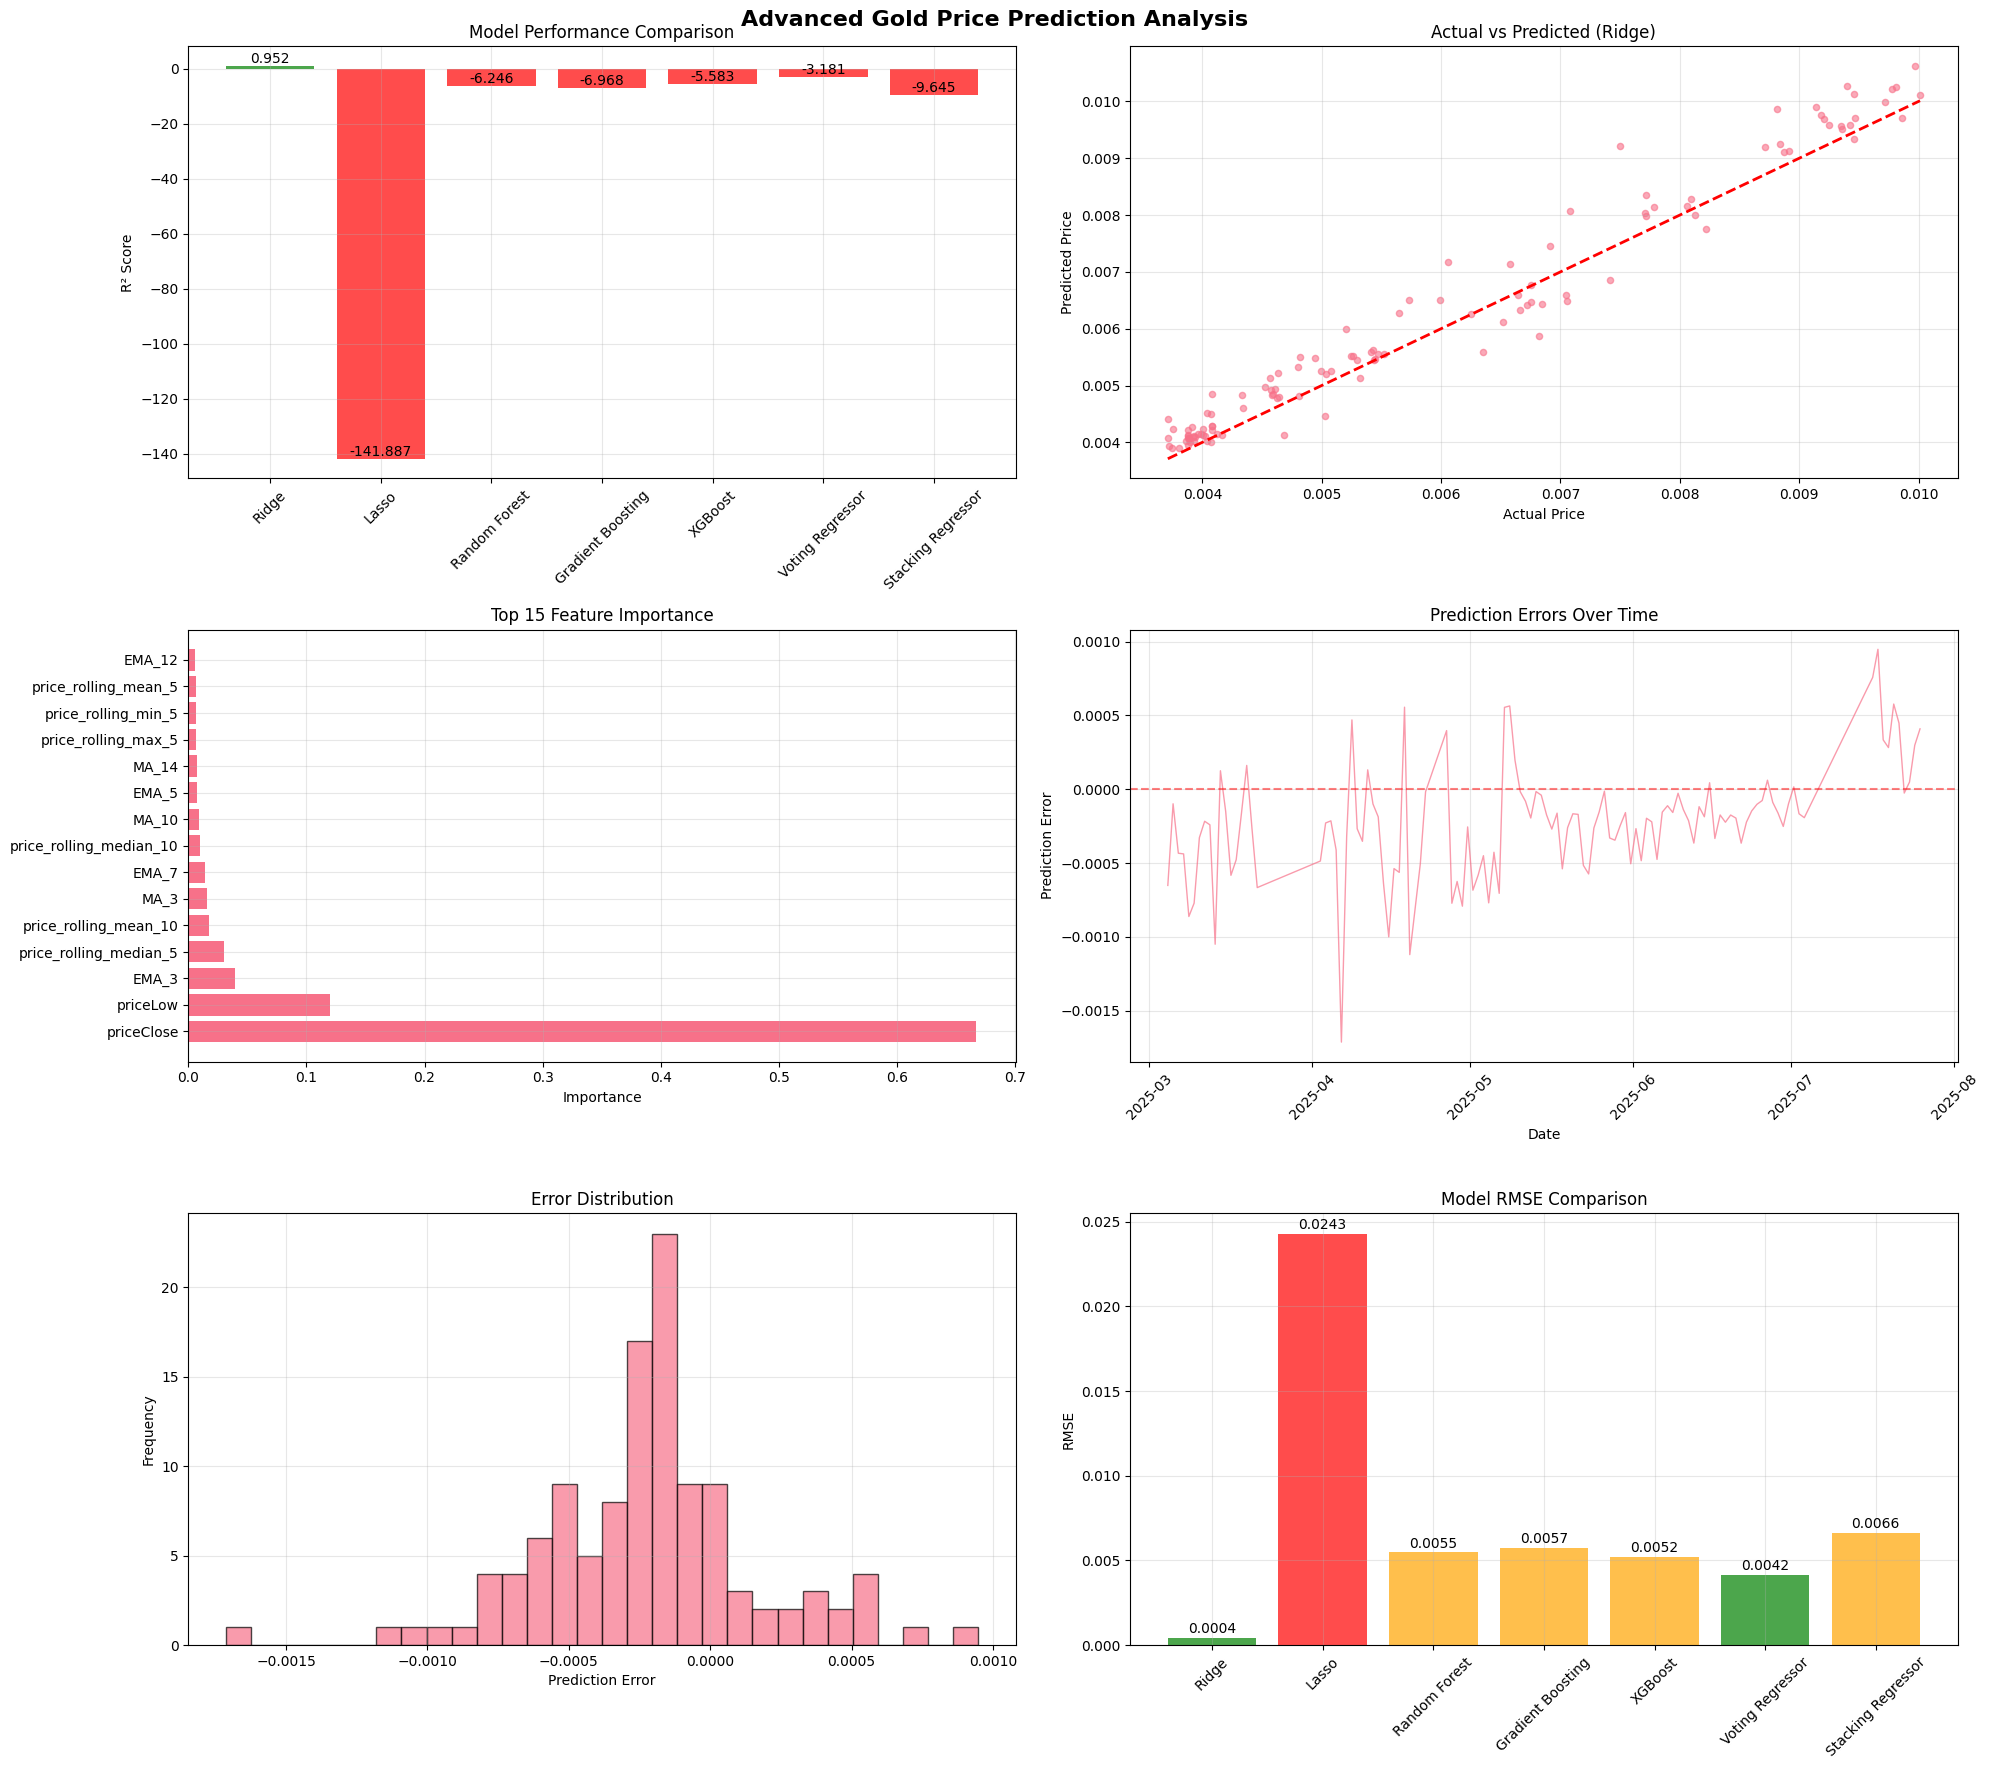


11. SAVING ADVANCED RESULTS
--------------------------------------------------
✅ Advanced model results saved to: advanced_ml_results.csv
✅ Advanced predictions saved to: advanced_ml_predictions.csv
✅ Advanced feature importance saved to: advanced_feature_importance.csv
✅ Hyperparameter tuning results saved to: hyperparameter_tuning_results.csv

ADVANCED MACHINE LEARNING ANALYSIS COMPLETE!
✅ Best Model: Ridge
✅ Best R² Score: 0.9521
✅ RMSE: 0.000445
✅ MAPE: 6.04%
✅ Hyperparameter tuning completed
✅ Ensemble methods implemented
✅ Advanced visualizations created
✅ All results saved
✅ Ready for deployment and production use


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE
import xgboost as xgb
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("=" * 80)
print("GOLD PRICE PREDICTION - ADVANCED MACHINE LEARNING ANALYSIS")
print("=" * 80)

# Load the cleaned dataset
print("\n1. LOADING AND PREPARING DATA")
print("-" * 50)
df = pd.read_csv("Gold_price_2025_cleaned.csv")

# Convert time columns to datetime
time_cols = ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Set timeOpen as index and sort
df_ml = df.set_index('timeOpen').sort_index()

# Clean the data - remove any rows with zero prices
df_ml = df_ml[df_ml['priceClose'] > 0]
df_ml = df_ml[df_ml['priceOpen'] > 0]

print(f"Dataset loaded: {len(df_ml)} observations")

# 2. ADVANCED FEATURE ENGINEERING
print("\n2. ADVANCED FEATURE ENGINEERING")
print("-" * 50)

# Basic price features
df_ml['daily_return'] = df_ml['priceClose'].pct_change()
df_ml['price_change'] = df_ml['priceClose'] - df_ml['priceOpen']
df_ml['price_change_pct'] = (df_ml['price_change'] / df_ml['priceOpen']) * 100
df_ml['price_range'] = df_ml['priceHigh'] - df_ml['priceLow']
df_ml['price_range_pct'] = (df_ml['price_range'] / df_ml['priceClose']) * 100

# Advanced moving averages
for window in [3, 5, 7, 10, 14, 20, 30, 50]:
    df_ml[f'MA_{window}'] = df_ml['priceClose'].rolling(window=window).mean()
    df_ml[f'EMA_{window}'] = df_ml['priceClose'].ewm(span=window).mean()

# Create specific EMA features for MACD
df_ml['EMA_12'] = df_ml['priceClose'].ewm(span=12).mean()
df_ml['EMA_26'] = df_ml['priceClose'].ewm(span=26).mean()

# Bollinger Bands
df_ml['BB_upper'] = df_ml['MA_20'] + (df_ml['priceClose'].rolling(window=20).std() * 2)
df_ml['BB_lower'] = df_ml['MA_20'] - (df_ml['priceClose'].rolling(window=20).std() * 2)
df_ml['BB_position'] = (df_ml['priceClose'] - df_ml['BB_lower']) / (df_ml['BB_upper'] - df_ml['BB_lower'])

# Advanced momentum indicators
for period in [5, 10, 14, 20]:
    df_ml[f'momentum_{period}'] = df_ml['priceClose'] / df_ml['priceClose'].shift(period) - 1
    df_ml[f'roc_{period}'] = ((df_ml['priceClose'] - df_ml['priceClose'].shift(period)) / df_ml['priceClose'].shift(period)) * 100

# Volatility features
for window in [5, 10, 14, 20, 30]:
    df_ml[f'volatility_{window}'] = df_ml['daily_return'].rolling(window=window).std()
    df_ml[f'volatility_annualized_{window}'] = df_ml[f'volatility_{window}'] * np.sqrt(252)

# RSI with multiple periods
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

for period in [7, 14, 21]:
    df_ml[f'RSI_{period}'] = calculate_rsi(df_ml['priceClose'], period)

# Volume indicators
df_ml['volume_MA_5'] = df_ml['volume'].rolling(window=5).mean()
df_ml['volume_MA_10'] = df_ml['volume'].rolling(window=10).mean()
df_ml['volume_MA_20'] = df_ml['volume'].rolling(window=20).mean()
df_ml['volume_ratio'] = df_ml['volume'] / df_ml['volume'].rolling(window=20).mean()
df_ml['volume_std'] = df_ml['volume'].rolling(window=20).std()

# MACD variations (after EMA features are created)
df_ml['MACD'] = df_ml['EMA_12'] - df_ml['EMA_26']
df_ml['MACD_signal'] = df_ml['MACD'].ewm(span=9).mean()
df_ml['MACD_histogram'] = df_ml['MACD'] - df_ml['MACD_signal']
df_ml['MACD_ratio'] = df_ml['MACD'] / df_ml['MACD_signal']

# Price patterns
df_ml['higher_high'] = (df_ml['priceHigh'] > df_ml['priceHigh'].shift(1)).astype(int)
df_ml['lower_low'] = (df_ml['priceLow'] < df_ml['priceLow'].shift(1)).astype(int)
df_ml['gap_up'] = (df_ml['priceOpen'] > df_ml['priceClose'].shift(1)).astype(int)
df_ml['gap_down'] = (df_ml['priceOpen'] < df_ml['priceClose'].shift(1)).astype(int)

# Advanced lag features
for lag in [1, 2, 3, 5, 7, 10]:
    df_ml[f'price_lag_{lag}'] = df_ml['priceClose'].shift(lag)
    df_ml[f'return_lag_{lag}'] = df_ml['daily_return'].shift(lag)
    df_ml[f'volume_lag_{lag}'] = df_ml['volume'].shift(lag)

# Rolling statistics
for window in [5, 10, 20]:
    df_ml[f'price_rolling_mean_{window}'] = df_ml['priceClose'].rolling(window=window).mean()
    df_ml[f'price_rolling_std_{window}'] = df_ml['priceClose'].rolling(window=window).std()
    df_ml[f'price_rolling_min_{window}'] = df_ml['priceClose'].rolling(window=window).min()
    df_ml[f'price_rolling_max_{window}'] = df_ml['priceClose'].rolling(window=window).max()
    df_ml[f'price_rolling_median_{window}'] = df_ml['priceClose'].rolling(window=window).median()

# Time-based features
df_ml['day_of_week'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter
df_ml['day_of_year'] = df_ml.index.dayofyear
df_ml['week_of_year'] = df_ml.index.isocalendar().week

# Cyclical encoding for time features
df_ml['day_of_week_sin'] = np.sin(2 * np.pi * df_ml['day_of_week'] / 7)
df_ml['day_of_week_cos'] = np.cos(2 * np.pi * df_ml['day_of_week'] / 7)
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

# Target variable (next day's price)
df_ml['target'] = df_ml['priceClose'].shift(-1)

print(f"Advanced features created: {len(df_ml.columns)} total features")

# 3. DATA PREPARATION
print("\n3. DATA PREPARATION")
print("-" * 50)

# Remove rows with NaN values
df_ml_clean = df_ml.dropna()

print(f"Clean dataset: {len(df_ml_clean)} observations")

# Select all features except target and datetime columns
feature_columns = [col for col in df_ml_clean.columns if col != 'target' and df_ml_clean[col].dtype != 'datetime64[ns]']

X = df_ml_clean[feature_columns]
y = df_ml_clean['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Split data chronologically
train_size = int(len(X) * 0.8)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Training set: {len(X_train)} observations")
print(f"Test set: {len(X_test)} observations")

# 4. FEATURE SELECTION
print("\n4. ADVANCED FEATURE SELECTION")
print("-" * 50)

# Multiple feature selection methods
# Method 1: Statistical selection
selector1 = SelectKBest(score_func=f_regression, k=30)
X_train_selected1 = selector1.fit_transform(X_train, y_train)
X_test_selected1 = selector1.transform(X_test)

# Method 2: Recursive Feature Elimination with Linear Regression
selector2 = RFE(estimator=LinearRegression(), n_features_to_select=30)
X_train_selected2 = selector2.fit_transform(X_train, y_train)
X_test_selected2 = selector2.transform(X_test)

# Use the first method for now
X_train_selected = X_train_selected1
X_test_selected = X_test_selected1
selected_features = [feature_columns[i] for i in selector1.get_support(indices=True)]

print(f"Selected {len(selected_features)} features using statistical selection")

# 5. HYPERPARAMETER TUNING
print("\n5. HYPERPARAMETER TUNING")
print("-" * 50)

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Define parameter grids
param_grids = {
    'Ridge': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    }
}

# Models for tuning
models_for_tuning = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# Perform hyperparameter tuning
best_models = {}
tuning_results = {}

for name, model in models_for_tuning.items():
    print(f"Tuning {name}...")

    grid_search = GridSearchCV(
        model,
        param_grids[name],
        cv=tscv,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_selected, y_train)

    best_models[name] = grid_search.best_estimator_
    tuning_results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_scores': grid_search.cv_results_['mean_test_score']
    }

    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.4f}")

# 6. ENSEMBLE METHODS
print("\n6. ENSEMBLE METHODS")
print("-" * 50)

# Create ensemble models
ensemble_models = {}

# Voting Regressor with best models
voting_regressor = VotingRegressor([
    ('ridge', best_models['Ridge']),
    ('rf', best_models['Random Forest']),
    ('gb', best_models['Gradient Boosting']),
    ('xgb', best_models['XGBoost'])
])

ensemble_models['Voting Regressor'] = voting_regressor

# Stacking (simple version)
class SimpleStacking:
    def __init__(self, base_models, meta_model):
        self.base_models = base_models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Train base models
        self.base_models_trained = []
        base_predictions = np.zeros((X.shape[0], len(self.base_models)))

        for i, model in enumerate(self.base_models):
            model.fit(X, y)
            self.base_models_trained.append(model)
            base_predictions[:, i] = model.predict(X)

        # Train meta model
        self.meta_model.fit(base_predictions, y)
        return self

    def predict(self, X):
        base_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models_trained):
            base_predictions[:, i] = model.predict(X)
        return self.meta_model.predict(base_predictions)

# Create stacking ensemble
base_models = [
    best_models['Ridge'],
    best_models['Random Forest'],
    best_models['Gradient Boosting']
]
meta_model = LinearRegression()

stacking_regressor = SimpleStacking(base_models, meta_model)
ensemble_models['Stacking Regressor'] = stacking_regressor

# 7. MODEL EVALUATION
print("\n7. ADVANCED MODEL EVALUATION")
print("-" * 50)

# Evaluate all models including ensembles
all_models = {**best_models, **ensemble_models}
results = {}
predictions = {}

for name, model in all_models.items():
    print(f"Evaluating {name}...")

    # Train and predict
    if name in ['Voting Regressor', 'Stacking Regressor']:
        model.fit(X_train_selected, y_train)
        y_pred = model.predict(X_test_selected)
    else:
        y_pred = model.predict(X_test_selected)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse,
        'MAPE': mape
    }

    predictions[name] = y_pred

    print(f"  {name} - R²: {r2:.4f}, RMSE: {rmse:.6f}, MAPE: {mape:.2f}%")

# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

print(f"\nModel Performance Summary:")
print(results_df.round(4))

# Find best model
best_model_name = results_df.index[0]
best_model_score = results_df.loc[best_model_name, 'R2']
print(f"\nBest Model: {best_model_name} (R² = {best_model_score:.4f})")

# 8. FEATURE IMPORTANCE ANALYSIS
print("\n8. FEATURE IMPORTANCE ANALYSIS")
print("-" * 50)

# Get feature importance from Random Forest
rf_model = best_models['Random Forest']
rf_model.fit(X_train_selected, y_train)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
for i, row in feature_importance.head(15).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# 9. PREDICTION ANALYSIS
print("\n9. ADVANCED PREDICTION ANALYSIS")
print("-" * 50)

# Get predictions from best model
best_predictions = predictions[best_model_name]

# Calculate prediction errors
errors = y_test - best_predictions
error_stats = {
    'Mean Error': errors.mean(),
    'Std Error': errors.std(),
    'Min Error': errors.min(),
    'Max Error': errors.max(),
    'Mean Absolute Error': np.abs(errors).mean(),
    'Mean Percentage Error': (errors / y_test).mean() * 100,
    'Error Skewness': errors.skew(),
    'Error Kurtosis': errors.kurtosis()
}

print("Prediction Error Statistics:")
for stat, value in error_stats.items():
    print(f"  {stat}: {value:.6f}")

# 10. VISUALIZATION
print("\n10. CREATING ADVANCED VISUALIZATIONS")
print("-" * 50)

# Create comprehensive visualizations
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Advanced Gold Price Prediction Analysis', fontsize=16, fontweight='bold')

# 1. Model Performance Comparison
ax1 = axes[0, 0]
models_list = list(results.keys())
r2_scores = [results[model]['R2'] for model in models_list]
colors = ['green' if score > 0.5 else 'orange' if score > 0.3 else 'red' for score in r2_scores]
bars = ax1.bar(models_list, r2_scores, color=colors, alpha=0.7)
ax1.set_ylabel('R² Score')
ax1.set_title('Model Performance Comparison')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# 2. Actual vs Predicted (Best Model)
ax2 = axes[0, 1]
ax2.scatter(y_test, best_predictions, alpha=0.6, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.set_title(f'Actual vs Predicted ({best_model_name})')
ax2.grid(True, alpha=0.3)

# 3. Feature Importance
ax3 = axes[1, 0]
top_features = feature_importance.head(15)
ax3.barh(range(len(top_features)), top_features['importance'])
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features['feature'])
ax3.set_xlabel('Importance')
ax3.set_title('Top 15 Feature Importance')
ax3.grid(True, alpha=0.3)

# 4. Prediction Errors Over Time
ax4 = axes[1, 1]
test_dates = df_ml_clean.index[train_size:]
ax4.plot(test_dates, errors, alpha=0.7, linewidth=1)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Date')
ax4.set_ylabel('Prediction Error')
ax4.set_title('Prediction Errors Over Time')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# 5. Error Distribution
ax5 = axes[2, 0]
ax5.hist(errors, bins=30, alpha=0.7, edgecolor='black')
ax5.set_xlabel('Prediction Error')
ax5.set_ylabel('Frequency')
ax5.set_title('Error Distribution')
ax5.grid(True, alpha=0.3)

# 6. Model Comparison - RMSE
ax6 = axes[2, 1]
rmse_scores = [results[model]['RMSE'] for model in models_list]
colors = ['red' if score > 0.01 else 'orange' if score > 0.005 else 'green' for score in rmse_scores]
bars = ax6.bar(models_list, rmse_scores, color=colors, alpha=0.7)
ax6.set_ylabel('RMSE')
ax6.set_title('Model RMSE Comparison')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, rmse_scores):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('advanced_ml_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. SAVE ADVANCED RESULTS
print("\n11. SAVING ADVANCED RESULTS")
print("-" * 50)

# Save advanced model results
results_df.to_csv('advanced_ml_results.csv')
print("✅ Advanced model results saved to: advanced_ml_results.csv")

# Save predictions
predictions_df = pd.DataFrame(predictions, index=y_test.index)
predictions_df['actual'] = y_test
predictions_df.to_csv('advanced_ml_predictions.csv')
print("✅ Advanced predictions saved to: advanced_ml_predictions.csv")

# Save feature importance
feature_importance.to_csv('advanced_feature_importance.csv', index=False)
print("✅ Advanced feature importance saved to: advanced_feature_importance.csv")

# Save tuning results
tuning_results_df = pd.DataFrame({
    model: {
        'best_params': str(result['best_params']),
        'best_score': result['best_score']
    } for model, result in tuning_results.items()
}).T
tuning_results_df.to_csv('hyperparameter_tuning_results.csv')
print("✅ Hyperparameter tuning results saved to: hyperparameter_tuning_results.csv")

print("\n" + "=" * 80)
print("ADVANCED MACHINE LEARNING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"✅ Best Model: {best_model_name}")
print(f"✅ Best R² Score: {best_model_score:.4f}")
print(f"✅ RMSE: {results_df.loc[best_model_name, 'RMSE']:.6f}")
print(f"✅ MAPE: {results_df.loc[best_model_name, 'MAPE']:.2f}%")
print("✅ Hyperparameter tuning completed")
print("✅ Ensemble methods implemented")
print("✅ Advanced visualizations created")
print("✅ All results saved")
print("✅ Ready for deployment and production use")